# 3. Projekat iz predmeta **Mašinsko učenje**
**Dataset:**  
[Sleep Patterns vs Daily Performance](https://www.kaggle.com/datasets/zulqarnain11/sleep-patterns-vs-daily-performance/data)

U ovom projektu bavimo se problemom **regresije**, koristeći dataset o obrascima spavanja i dnevnim performansama.
Skup podataka sadrži informacije o navikama spavanja i svakodnevnim faktorima koji utiču na produktivnost, na osnovu kojih se predviđa numerička vrednost produktivnosti.

## Osobine (feature-i)
- **Sleep_Hours** - broj sati sna
- **Sleep_Quality_Score** - ocena kvaliteta sna
- **Energy_Level** - nivo energije tokom dana
- **Caffeine_Intake_mg** - unos kofeina u miligramima
- **Screen_Time_Before_Bed** - vreme provedeno ispred ekrana pre spavanja
- **Error_Rate** - stopa grešaka pri radu
- **Morning_Mood** - raspoloženje ujutru (ordinalna kategorička promenljiva: Very Bad → Bad → Neutral → Good → Excellent)

## Setup i učitavanje
### Import biblioteka i setovanje konstantni

In [293]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

np.random.seed(42)
tf.random.set_seed(42)

### Učitavanje podataka i pregled strukture

In [294]:
dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')

dataset.info()
dataset.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 8 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Sleep_Hours              30000 non-null  float64
 1   Sleep_Quality_Score      30000 non-null  int64  
 2   Caffeine_Intake_mg       30000 non-null  float64
 3   Screen_Time_Before_Bed   30000 non-null  float64
 4   Morning_Mood             30000 non-null  object 
 5   Work_Productivity_Score  30000 non-null  int64  
 6   Error_Rate               30000 non-null  float64
 7   Energy_Level             30000 non-null  int64  
dtypes: float64(4), int64(3), object(1)
memory usage: 1.8+ MB


,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Work_Productivity_Score,Error_Rate,Energy_Level
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000
mean,6.987010,7.590433,198.492067,58.685500,73.637667,6.499266,8.656567
std,1.468244,1.518826,133.939111,54.993704,13.119905,3.785921,1.330669
min,2.000000,1.000000,1.000000,0.000000,6.000000,0.000000,1.000000
25%,6.000000,7.000000,97.000000,17.000000,66.000000,3.757500,8.000000
50%,7.000000,8.000000,169.000000,42.000000,75.000000,6.140000,9.000000
75%,8.000000,9.000000,271.000000,84.000000,83.000000,8.890000,10.000000
max,10.000000,10.000000,600.000000,240.000000,100.000000,26.900000,10.000000


In [295]:
dataset.head()

,Sleep_Hours,Sleep_Quality_Score,Caffeine_Intake_mg,Screen_Time_Before_Bed,Morning_Mood,Work_Productivity_Score,Error_Rate,Energy_Level
0,7.7,7,498.0,107.0,Neutral,71,10.45,8
1,6.8,8,315.0,128.0,Good,80,6.49,10
2,8.0,10,412.0,34.0,Excellent,85,3.88,10
3,9.3,9,447.0,28.0,Good,85,3.18,10
4,6.6,7,177.0,57.0,Neutral,70,6.74,8


## Preprocesiranje podataka

### Uklanjanje duplikata

In [296]:
broj_duplikata = dataset.duplicated().sum()
print(f'Broj duplikata: {broj_duplikata}')

Broj duplikata: 0


### Analiza podataka

#### Analiza nedostajućih vrednosti

In [297]:
dataset.isnull().sum()

Sleep_Hours                0
Sleep_Quality_Score        0
Caffeine_Intake_mg         0
Screen_Time_Before_Bed     0
Morning_Mood               0
Work_Productivity_Score    0
Error_Rate                 0
Energy_Level               0
dtype: int64

### Preprocesiranje kolone <b>Morning_Mood</b>

Kolona <i>Morning_Mood</i> je ordinalna kategorička promenljiva sa prirodnim redosledom:
<i>Very Bad → Bad → Neutral → Good → Excellent</i>

Odrađeno je ordinalno enkodiranje koje čuva ovaj redosled, za razliku od One-Hot Encodinga koji bi
tretirao klase kao nezavisne.

In [298]:
mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
mood_map   = {m: i for i, m in enumerate(mood_order)}

dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)

print('Mapiranje Morning_Mood:')
for k, v in mood_map.items():
    print(f'  {v} -> {k}')
print()

Mapiranje Morning_Mood:
  0 -> Very Bad
  1 -> Bad
  2 -> Neutral
  3 -> Good
  4 -> Excellent



## EDA

#### Distribucija targeta <i>Work_Productivity_Score</i>

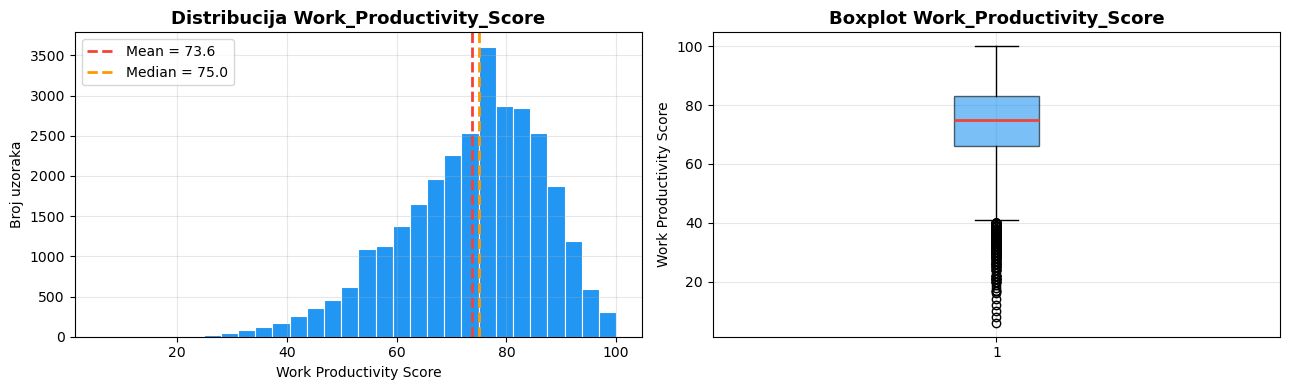

Min:    6
Max:    100
Mean:   73.64
Median: 75.00
Std:    13.12


In [299]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(dataset['Work_Productivity_Score'], bins=30,
             color='#2196F3', edgecolor='white', linewidth=0.8)
axes[0].set_title('Distribucija Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Work Productivity Score')
axes[0].set_ylabel('Broj uzoraka')
axes[0].axvline(dataset['Work_Productivity_Score'].mean(), color='#F44336',
                linewidth=2, linestyle='--', label=f'Mean = {dataset["Work_Productivity_Score"].mean():.1f}')
axes[0].axvline(dataset['Work_Productivity_Score'].median(), color='#FF9800',
                linewidth=2, linestyle='--', label=f'Median = {dataset["Work_Productivity_Score"].median():.1f}')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].boxplot(dataset['Work_Productivity_Score'], vert=True, patch_artist=True,
                boxprops=dict(facecolor='#2196F3', alpha=0.6),
                medianprops=dict(color='#F44336', linewidth=2))
axes[1].set_title('Boxplot Work_Productivity_Score', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Work Productivity Score')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f'Min:    {dataset["Work_Productivity_Score"].min():.0f}')
print(f'Max:    {dataset["Work_Productivity_Score"].max():.0f}')
print(f'Mean:   {dataset["Work_Productivity_Score"].mean():.2f}')
print(f'Median: {dataset["Work_Productivity_Score"].median():.2f}')
print(f'Std:    {dataset["Work_Productivity_Score"].std():.2f}')

Zapažanja:

Distribucija je negativno asimetrična: Većina ljudi ima visoku produktinost sa relativno malo neproduktivnih dana.

Boxplot pokazuje da se outlieri pojavljuju samo u donjoj granici (ispod 40) i predstavljaju ekstremno niske vrednosti.

### Korelaciona matrica feature-a

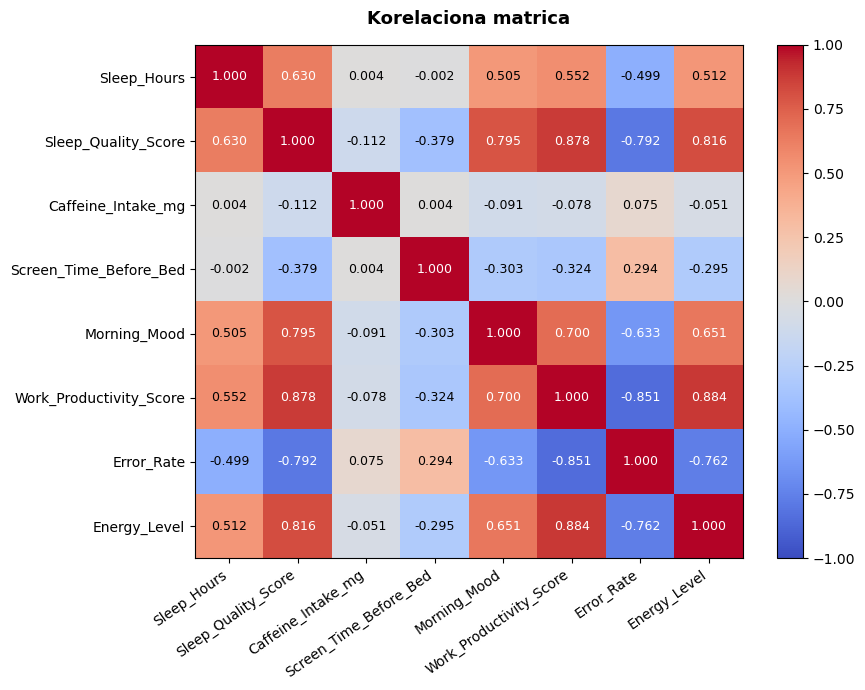

Korelacija sa Work_Productivity_Score (sortirano):
Energy_Level              0.884053
Sleep_Quality_Score       0.877801
Morning_Mood              0.700160
Sleep_Hours               0.552399
Caffeine_Intake_mg       -0.077774
Screen_Time_Before_Bed   -0.323615
Error_Rate               -0.851021


In [300]:
corr = dataset.corr()

fig, ax = plt.subplots(figsize=(9, 7))
im = ax.imshow(corr.values, cmap='coolwarm', vmin=-1, vmax=1, aspect='auto')

labels = corr.columns.tolist()
ax.set_xticks(range(len(labels)))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=10)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.set_title('Korelaciona matrica', fontsize=13, fontweight='bold', pad=15)

for i in range(len(labels)):
    for j in range(len(labels)):
        val = corr.values[i, j]
        color = 'white' if abs(val) > 0.6 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center', fontsize=9, color=color)

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

print('Korelacija sa Work_Productivity_Score (sortirano):')
print(corr['Work_Productivity_Score'].drop('Work_Productivity_Score').sort_values(ascending=False).to_string())

Zapažanja:

- Najjači prediktori produktivnosti su `Energy_Level` (r = 0.884), `Sleep_Quality_Score`(r = 0.878) i `Error_Rate` (r = -0.851), dok `Caffeine_Intake_mg` (r = -0.078).
- Postoji multikolinearnost između `Sleep_Quality_Score`, `Energy_Level`, `Error_Rate` i `Morning_Mood`.


### VIF analiza za multikolinearnost

Feature                           VIF  Interpretacija
------------------------------------------------------------
Sleep_Quality_Score            156.69  ⚠ Ozbiljan problem
Energy_Level                   102.48  ⚠ Ozbiljan problem
Sleep_Hours                     44.45  ⚠ Ozbiljan problem
Morning_Mood                    27.40  ⚠ Ozbiljan problem
Error_Rate                       3.80    Umerena kolinearnost
Caffeine_Intake_mg               3.25    Umerena kolinearnost
Screen_Time_Before_Bed           2.71    Umerena kolinearnost


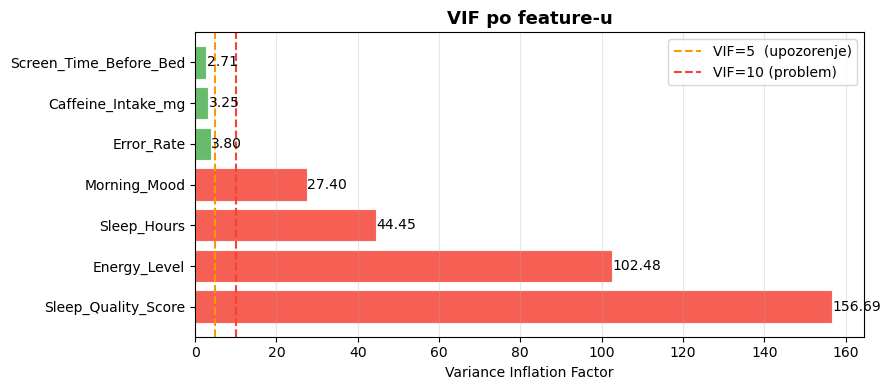

In [301]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
 
feature_cols = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']
 
X_vif = dataset[feature_cols].astype(float)
 
vif_data = pd.DataFrame({
    'Feature': feature_cols,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]
}).sort_values('VIF', ascending=False).reset_index(drop=True)
 
print(f"{'Feature':<28} {'VIF':>8}  {'Interpretacija'}")
print('-' * 60)
for _, row in vif_data.iterrows():
    if row['VIF'] > 10:
        interp = '⚠ Ozbiljan problem'
    elif row['VIF'] > 5:
        interp = '⚠ Visoka kolinearnost'
    elif row['VIF'] > 2:
        interp = '  Umerena kolinearnost'
    else:
        interp = '  Prihvatljivo'
    print(f"{row['Feature']:<28} {row['VIF']:>8.2f}  {interp}")
 
fig, ax = plt.subplots(figsize=(9, 4))
colors_vif = ['#F44336' if v > 10 else '#FF9800' if v > 5 else '#4CAF50'
              for v in vif_data['VIF']]
bars = ax.barh(vif_data['Feature'], vif_data['VIF'],
               color=colors_vif, edgecolor='white', linewidth=0.8, alpha=0.85)
ax.axvline(x=5,  color='#FF9800', linestyle='--', linewidth=1.5, label='VIF=5  (upozorenje)')
ax.axvline(x=10, color='#F44336', linestyle='--', linewidth=1.5, label='VIF=10 (problem)')
ax.set_title('VIF po feature-u', fontsize=13, fontweight='bold')
ax.set_xlabel('Variance Inflation Factor')
ax.legend()
ax.grid(True, alpha=0.3, axis='x')
for bar, val in zip(bars, vif_data['VIF']):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.2f}', va='center', fontsize=10)
plt.tight_layout()
plt.show()

Zapažanja:

VIF analiza potvrđuje multikolinearnost gde su najproblematičniji fičeri `Sleep_Quality_Score`i `Energy_Level`(mogu da se rekonstruišu iz kombinacije ostalih fičera) - Potencijalno mogu da se izbace i da se trenira model sa 5 fičera.


### PCA analiza za multikolineranost

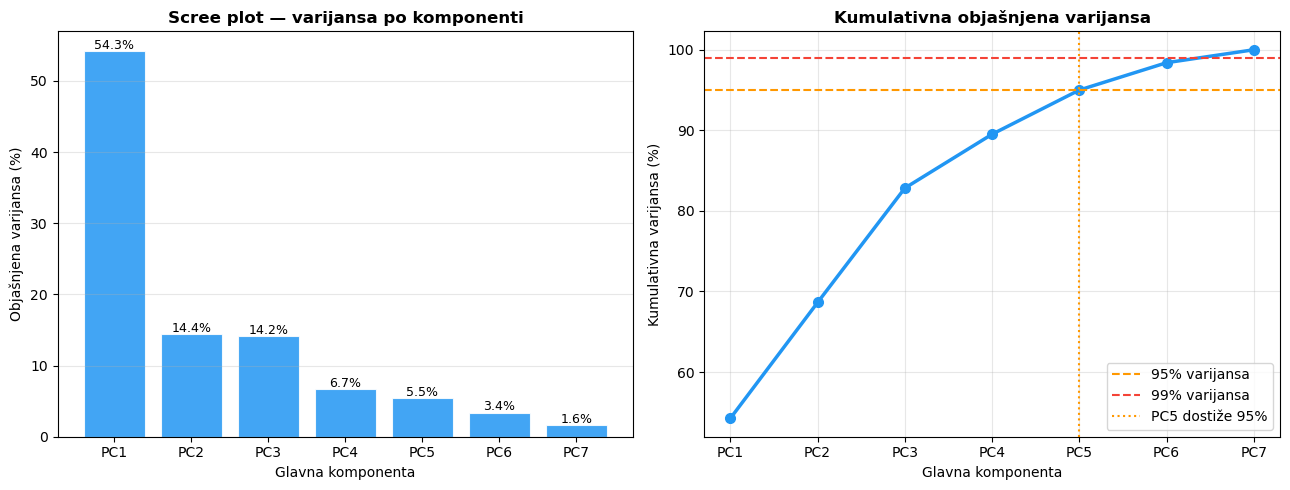

In [302]:
from sklearn.decomposition import PCA
 
feature_cols = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']
 
X_raw = dataset[feature_cols].astype(float).values
scaler_pca = StandardScaler()
X_scaled_pca = scaler_pca.fit_transform(X_raw)
 
pca_full = PCA()
pca_full.fit(X_scaled_pca)
 
explained      = pca_full.explained_variance_ratio_
cumulative     = np.cumsum(explained)
n_95           = np.argmax(cumulative >= 0.95) + 1
n_99           = np.argmax(cumulative >= 0.99) + 1
 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
pc_labels = [f'PC{i+1}' for i in range(len(explained))]
 
axes[0].bar(pc_labels, explained * 100, color='#2196F3',
            edgecolor='white', linewidth=0.8, alpha=0.85)
axes[0].set_title('Scree plot — varijansa po komponenti',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Glavna komponenta')
axes[0].set_ylabel('Objašnjena varijansa (%)')
axes[0].grid(True, alpha=0.3, axis='y')
for i, v in enumerate(explained * 100):
    axes[0].text(i, v + 0.3, f'{v:.1f}%', ha='center', fontsize=9)
 
axes[1].plot(pc_labels, cumulative * 100,
             color='#2196F3', linewidth=2.5, marker='o', markersize=7)
axes[1].axhline(y=95, color='#FF9800', linestyle='--',
                linewidth=1.5, label='95% varijansa')
axes[1].axhline(y=99, color='#F44336', linestyle='--',
                linewidth=1.5, label='99% varijansa')
axes[1].axvline(x=n_95-1, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'PC{n_95} dostiže 95%')
axes[1].set_title('Kumulativna objašnjena varijansa',
                  fontsize=12, fontweight='bold')
axes[1].set_xlabel('Glavna komponenta')
axes[1].set_ylabel('Kumulativna varijansa (%)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Zapažanje:

- Postoji dominantna komponenta(objašnjava 54.3% ukupne varijanse)
- Redukacija sa 7 na 5 komponenti nosi ukupno 95% varijanse
- Za ukupno 99% varijanse potrebno je svih 7 komponenti - svaka nosi neku jedinstvenu informaciju

### PCA Loadings Heatmapa

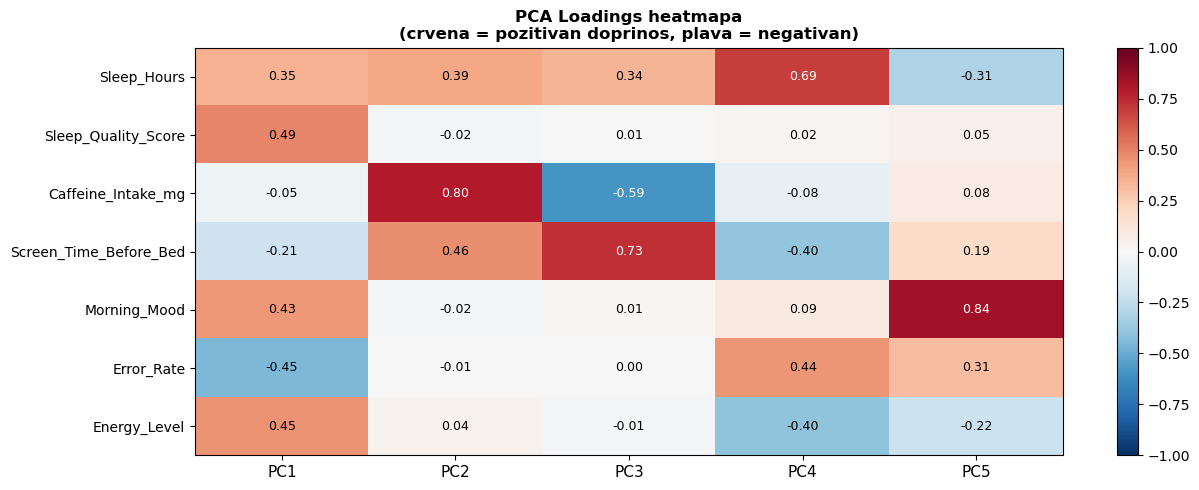

In [303]:
pca_show = PCA(n_components=n_95)
pca_show.fit(X_scaled_pca)
 
loadings = pd.DataFrame(
    pca_show.components_.T,
    index=feature_cols,
    columns=[f'PC{i+1}' for i in range(n_95)]
)
 
fig, ax = plt.subplots(figsize=(n_95 * 2 + 3, 5))
im = ax.imshow(loadings.values, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(n_95))
ax.set_xticklabels([f'PC{i+1}' for i in range(n_95)], fontsize=11)
ax.set_yticks(range(len(feature_cols)))
ax.set_yticklabels(feature_cols, fontsize=10)
ax.set_title('PCA Loadings heatmapa\n(crvena = pozitivan doprinos, plava = negativan)',
             fontsize=12, fontweight='bold')
for i in range(len(feature_cols)):
    for j in range(n_95):
        val = loadings.values[i, j]
        color = 'white' if abs(val) > 0.5 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=9, color=color)
plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.show()

Zapažanje:
- <b>PC1 (54% varijanse)</b> - faktor kvaliteta odmora i produktivnosti
    - Osoba koja dobro spava ima energije, dbro je raspoložena i manje greši.

- <b>PC2 (14% varijanse)</b> - faktor stimulansa
    - kofein i vreme provedeno uz ekran su spoljni stimulansi koji su međusobno slabo korelisani sa snom i produktivnošću, ali mogu biti korelisani međusobno 

- <b>PC3 (14% varijanse)</b> - kontrast kofeina i vreme provedeno uz ekran
    - hvata razliku osoba koje konzumiraju kofein a ne provode dosta vremena uz ekran i obrnuto

- <b>PC4 (6.7% varijanse)</b> - faktor sati sna nezavisno od kvaliteta
    - hvata situaciju gde neko spava dugo ali ne nužno kvalitetno

- <b>PC5 (5.5% varijanse) </b> - faktor raspoloženja nezavisno od sna
    - hvata varijabilnost raspoloženja koja nije objašnjena kvalitetom sna - možda stres, lični faktori, itd.

#### Scatter plot - Feature-i vs <i>Work_Productivity_Score</i>

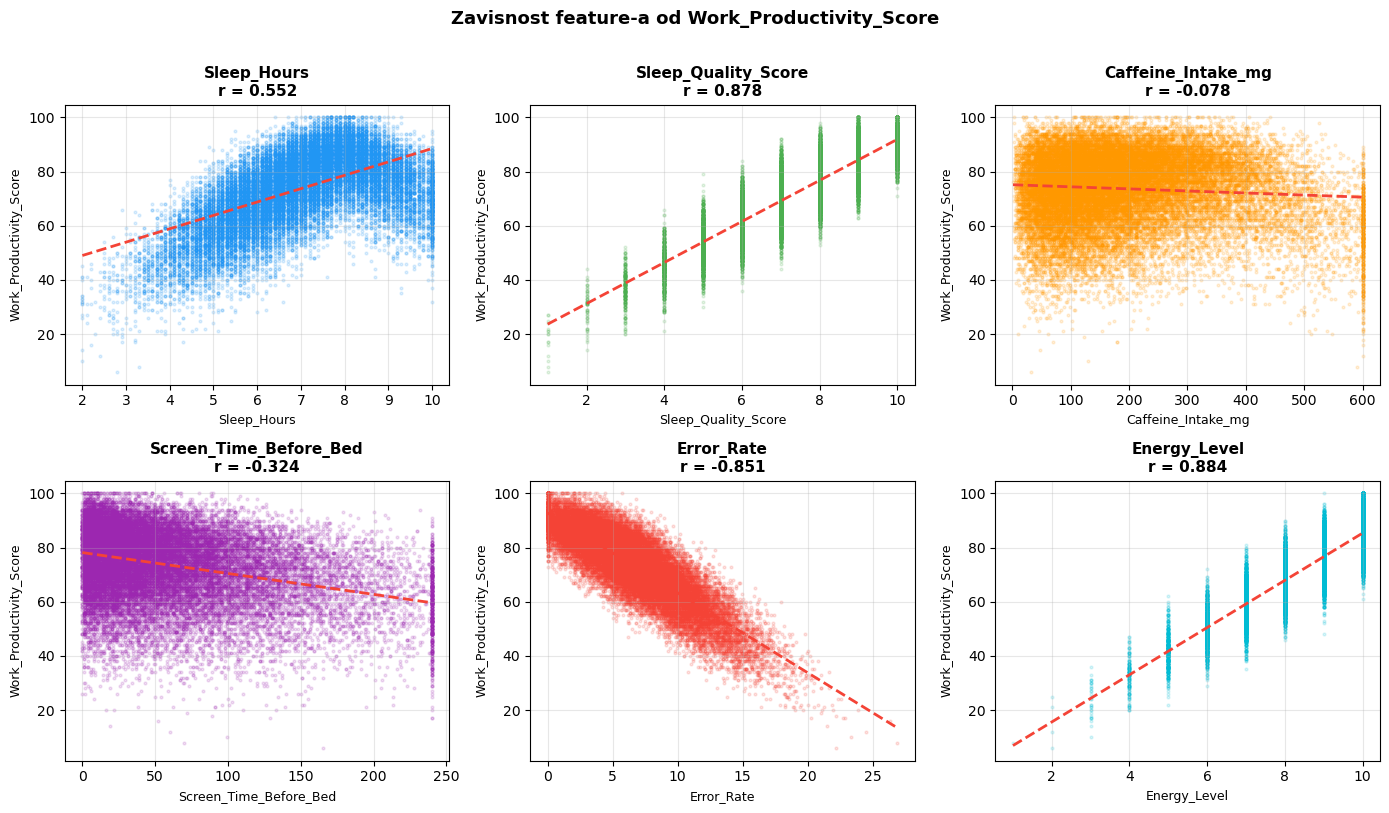

In [304]:
num_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()
colors_scatter = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336', '#00BCD4']

for i, col in enumerate(num_features):
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    axes[i].scatter(dataset[col], dataset['Work_Productivity_Score'],
                    alpha=0.15, s=4, color=colors_scatter[i])
    z = np.polyfit(dataset[col], dataset['Work_Productivity_Score'], 1)
    p = np.poly1d(z)
    x_line = np.linspace(dataset[col].min(), dataset[col].max(), 100)
    axes[i].plot(x_line, p(x_line), color='#F44336', linewidth=2, linestyle='--')
    axes[i].set_title(f'{col}\nr = {r:.3f}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col, fontsize=9)
    axes[i].set_ylabel('Work_Productivity_Score', fontsize=9)
    axes[i].grid(True, alpha=0.3)

plt.suptitle('Zavisnost feature-a od Work_Productivity_Score',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanja:

- Sleep Hours
    - umerena, blago nelinearna zavisnost
    - sa više od 8 sati sna produktivnost prestaje da raste 

- Sleep Quality Score i Energy Level
    - prikazuju gotovo identično ponašanje - linearna zavisnost
    - sa povećanjem kvaliteta sna/ nivoom energije se povećava i produktivnost

- Caffeine Intake in miligrams
    - horizontalna trend linija 
    - tačke su ravnomerno raspoređene celom dužinom
    - koefin gotovo uopšte ne predviđa produktivnost

- Screen Time Before Bed
    - slabo negativna veza
    - veza postoji ali je jako slaba i nije pouzdana za predikciju

- Error Rate
    -  linearna negativna veza
    - sa porastom broja grešaka produktivnost pada

#### <i>Morning_Mood</i> vs <i>Work_Productivity_Score</i>

C:\Users\Asus\AppData\Local\Temp\ipykernel_14436\3239374769.py:8: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,


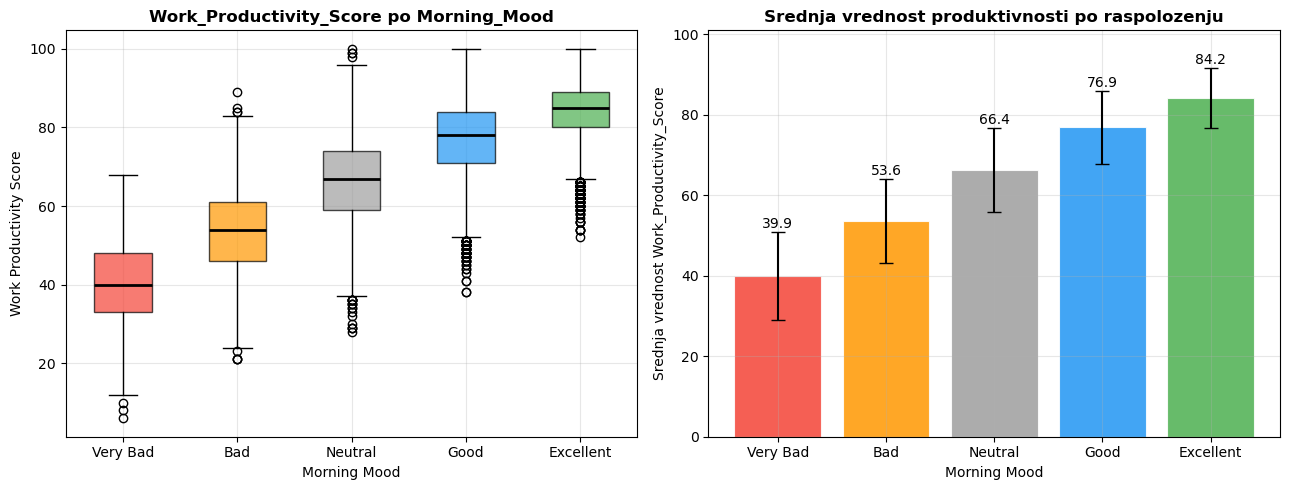

In [305]:
mood_labels = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
colors_mood = ['#F44336', '#FF9800', '#9E9E9E', '#2196F3', '#4CAF50']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

mood_groups = [dataset[dataset['Morning_Mood'] == i]['Work_Productivity_Score']
               for i in range(5)]
bp = axes[0].boxplot(mood_groups, labels=mood_labels, patch_artist=True,
                     medianprops=dict(color='black', linewidth=2))
for patch, color in zip(bp['boxes'], colors_mood):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)
axes[0].set_title('Work_Productivity_Score po Morning_Mood', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Morning Mood')
axes[0].set_ylabel('Work Productivity Score')
axes[0].grid(True, alpha=0.3)

means = [g.mean() for g in mood_groups]
stds  = [g.std() for g in mood_groups]
axes[1].bar(mood_labels, means, color=colors_mood, edgecolor='white',
            linewidth=0.8, alpha=0.85, yerr=stds, capsize=5)
axes[1].set_title('Srednja vrednost produktivnosti po raspolozenju', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Morning Mood')
axes[1].set_ylabel('Srednja vrednost Work_Productivity_Score')
for i, (m, s) in enumerate(zip(means, stds)):
    axes[1].text(i, m + s + 1, f'{m:.1f}', ha='center', fontsize=10)
axes[1].grid(True, alpha=0.3)
axes[1].set_ylim(0, max(means) * 1.2)

plt.tight_layout()
plt.show()

Zapažanje:

- Grafik pokazuje jasnu i monotonu vezu između jutarnjeg raspoloženja i produktivnosti.
- Postoje outlieri u donjoj granici u svakoj kategoriji, i outlieri u gronjoj granici kod `Bad` i `Neutral` jutarnjeg raspoloženja.
- Ima dosta rasipanja (osoba sa `Good` jutarnjim raspoloženjem može imati istu produktivnost kao neko sa `Very Bad` jutarnjim raspoloženjem) - fičer nije dovoljno jak prediktor 

#### Heatmapa: Uticaj kvaliteta i dužine sna na produktivnost

C:\Users\Asus\AppData\Local\Temp\ipykernel_14436\2373501981.py:5: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  pivot = dataset.pivot_table(


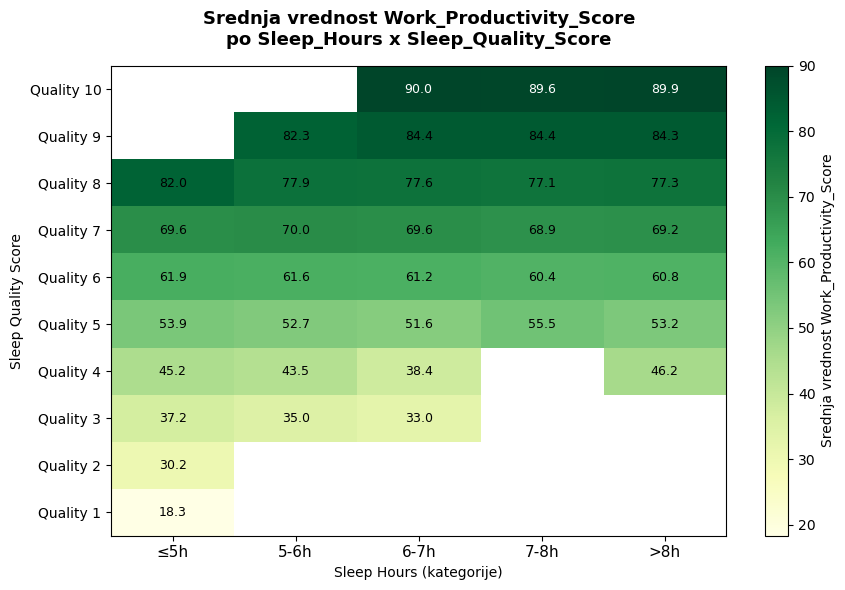

In [306]:
dataset['sleep_bin'] = pd.cut(dataset['Sleep_Hours'],
                               bins=[1.9, 5, 6, 7, 8, 10.1],
                               labels=['≤5h', '5-6h', '6-7h', '7-8h', '>8h'])

pivot = dataset.pivot_table(
    values='Work_Productivity_Score',
    index='Sleep_Quality_Score',
    columns='sleep_bin',
    aggfunc='mean'
)
pivot = pivot.sort_index(ascending=False)

fig, ax = plt.subplots(figsize=(9, 6))
im = ax.imshow(pivot.values, cmap='YlGn', aspect='auto',
               vmin=pivot.values[~np.isnan(pivot.values)].min(),
               vmax=pivot.values[~np.isnan(pivot.values)].max())

ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=11)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels([f'Quality {v}' for v in pivot.index], fontsize=10)
ax.set_title('Srednja vrednost Work_Productivity_Score\npo Sleep_Hours x Sleep_Quality_Score',
             fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Sleep Hours (kategorije)')
ax.set_ylabel('Sleep Quality Score')

for i in range(len(pivot.index)):
    for j in range(len(pivot.columns)):
        val = pivot.values[i, j]
        if not np.isnan(val):
            ax.text(j, i, f'{val:.1f}', ha='center', va='center', fontsize=9,
                    color='black' if val < 85 else 'white')

plt.colorbar(im, ax=ax, label='Srednja vrednost Work_Productivity_Score')
plt.tight_layout()
plt.show()

dataset = dataset.drop(columns=['sleep_bin'])

Zapažanja:

- Kvalitet sna dominantno određuje produktivnost dok broj sati sna ne doprinosi puno.
- Vrednosti za redove Q7-Q10 su jako slične kroz sve kategorije trajanja sna
- Prazne ćelije gore levo i dole desno - osobe koje spavaju kratko retko imaju visok kvalitet sna, i osobe koje spavaju duge retko imaju loš kvalitet sna
- Q8 pokazuje najveću vrednost u kategoriji <= 5 

#### Distribucija svih feature-a

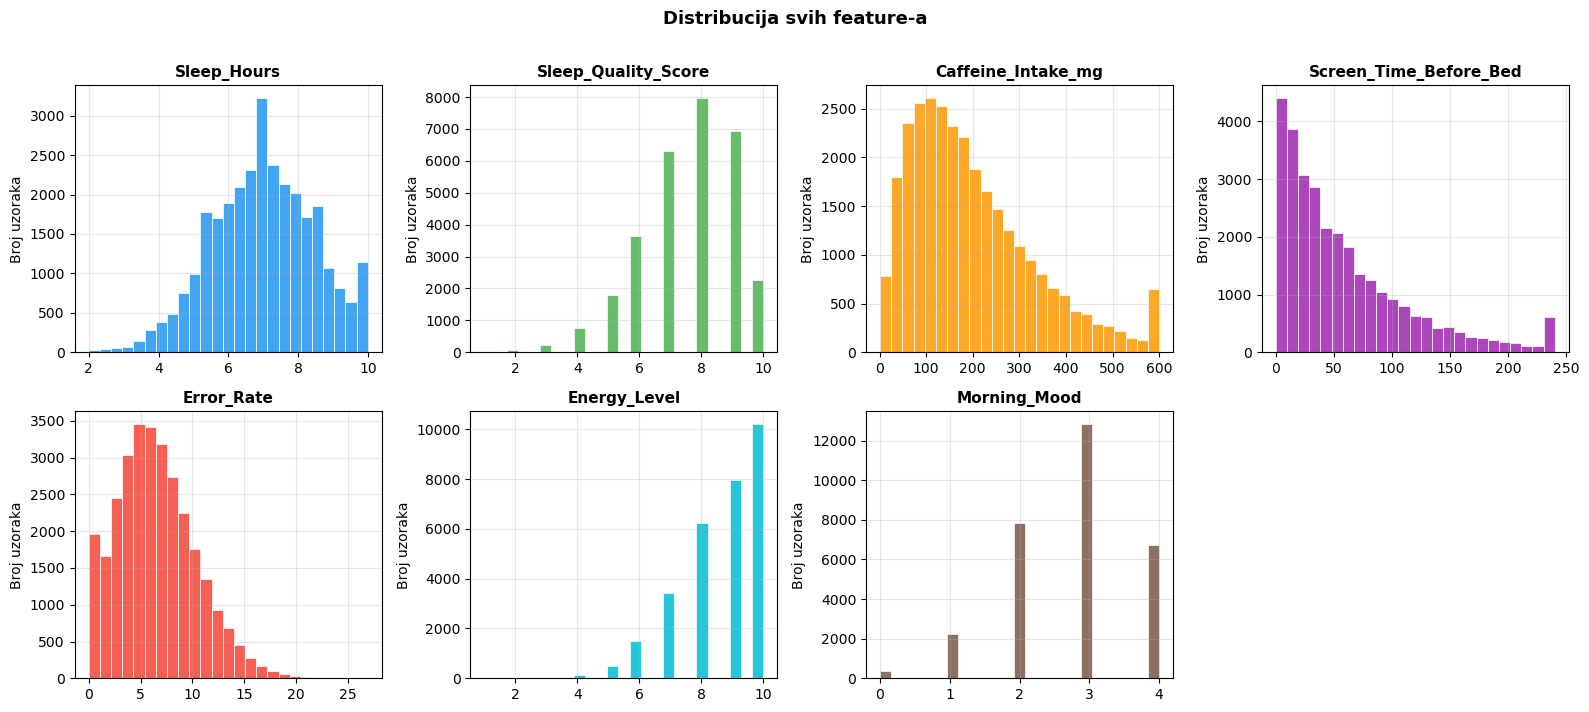

In [307]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548','#607D8B']

for i, col in enumerate(all_features):
    axes[i].hist(dataset[col], bins=25, color=palette[i],
                 edgecolor='white', linewidth=0.6, alpha=0.85)
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_ylabel('Broj uzoraka')
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Distribucija svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanja: 
- `Sleep Quality Score`, `Morning Mood` `Energy Level` su sa pravilnim stepenastim oblikom
- `Sleep Hours` i `Error Rate` imaju približno normalnu simetričnu distribuciju
- `Coffeine Intake` i `Screen Time Before Bed` imaju pozitivnu asimetričnu distribuciju

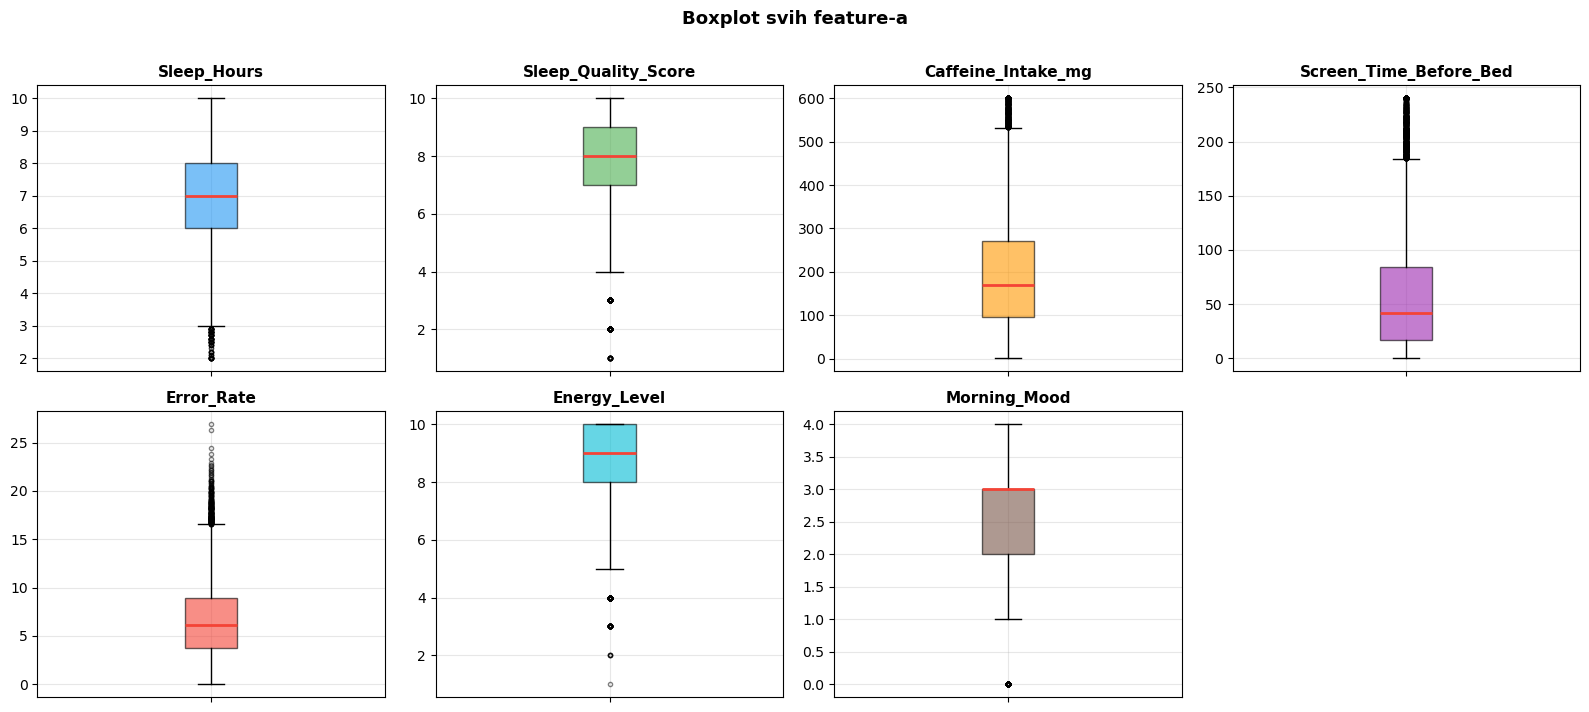

In [308]:
all_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                'Screen_Time_Before_Bed', 'Error_Rate', 'Energy_Level',
                'Morning_Mood']

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
axes = axes.flatten()
palette = ['#2196F3','#4CAF50','#FF9800','#9C27B0','#F44336','#00BCD4','#795548']

for i, col in enumerate(all_features):
    bp = axes[i].boxplot(dataset[col], vert=True, patch_artist=True,
                         boxprops=dict(facecolor=palette[i], alpha=0.6),
                         medianprops=dict(color='#F44336', linewidth=2),
                         flierprops=dict(marker='o', markersize=3, alpha=0.5))
    axes[i].set_title(col, fontsize=11, fontweight='bold')
    axes[i].set_xticklabels([])
    axes[i].grid(True, alpha=0.3)

axes[-1].set_visible(False)

plt.suptitle('Boxplot svih feature-a', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

Zapažanje: Sve kolone poseduju outlier-e

## Analiza i obrada outliera
Korišćena je IQR metoda zbog asimetrične distribucije samo nad kolonama koje nemaju diskretne vrednosti (svaki outlier je ovde validna kategorija)

In [309]:
cols_to_check = ['Work_Productivity_Score', 'Caffeine_Intake_mg', 'Screen_Time_Before_Bed', 'Error_Rate', 'Sleep_Hours']

print(f'{"Kolona":<28} {"Q1":>7} {"Q3":>7} {"IQR":>7} {"Outlieri":>10} {"Procenat":>10}')
print('-' * 75)
for col in cols_to_check:
    Q1  = dataset[col].quantile(0.25)
    Q3  = dataset[col].quantile(0.75)
    IQR = Q3 - Q1
    mask = (dataset[col] < Q1 - 1.5 * IQR) | (dataset[col] > Q3 + 1.5 * IQR)
    n_out = mask.sum()
    print(f'{col:<28} {Q1:>7.1f} {Q3:>7.1f} {IQR:>7.1f} {n_out:>10} {n_out/len(dataset)*100:>9.2f}%')

print()

Kolona                            Q1      Q3     IQR   Outlieri   Procenat
---------------------------------------------------------------------------
Work_Productivity_Score         66.0    83.0    17.0        482      1.61%
Caffeine_Intake_mg              97.0   271.0   174.0        896      2.99%
Screen_Time_Before_Bed          17.0    84.0    67.0       1343      4.48%
Error_Rate                       3.8     8.9     5.1        288      0.96%
Sleep_Hours                      6.0     8.0     2.0        117      0.39%



#### Odluka:
Outlieri se <b>ne uklanjaju</b> jer:
- Predstavljaju realne vrednosti (npr. 600mg kofeina dnevno je ekstremno ali moguće)
- Procenat outliera je mali (< 5% po koloni)

### Podela dataseta na Train/Validation/Test

In [310]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = dataset.drop(columns=['Work_Productivity_Score']).astype(float).values
y = dataset['Work_Productivity_Score'].values.astype(float)

X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42
)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_val_s   = scaler.transform(X_val)
X_test_s  = scaler.transform(X_test)

print(f"Train:      {X_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_test_s.shape[0]:,} uzoraka")

Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka


### Baseline Mean Predictor

In [311]:
y_mean_pred = np.full_like(y_test, fill_value=y_train.mean())

mae_baseline  = mean_absolute_error(y_test, y_mean_pred)
rmse_baseline = np.sqrt(mean_squared_error(y_test, y_mean_pred))
r2_baseline   = r2_score(y_test, y_mean_pred)

print(f"  MAE:  {mae_baseline:.4f}")
print(f"  RMSE: {rmse_baseline:.4f}")
print(f"  R²:   {r2_baseline:.4f}")
print()
print(f"Uvek predviđa: {y_train.mean():.2f}")

  MAE:  10.3249
  RMSE: 12.9558
  R²:   -0.0001

Uvek predviđa: 73.67


## Baseline neuronska mreža

In [312]:
def build_baseline_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="Baseline_SleepNet")
    return model

baseline_model = build_baseline_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in baseline_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = baseline_model.count_params()
trainable = sum(w.numpy().size for w in baseline_model.trainable_weights)
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{baseline_model.name}"')
summary_df

Model: "Baseline_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [313]:
baseline_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [314]:
callbacks = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [315]:
history = baseline_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks,
    verbose=0
)

Restoring model weights from the end of the best epoch: 99.


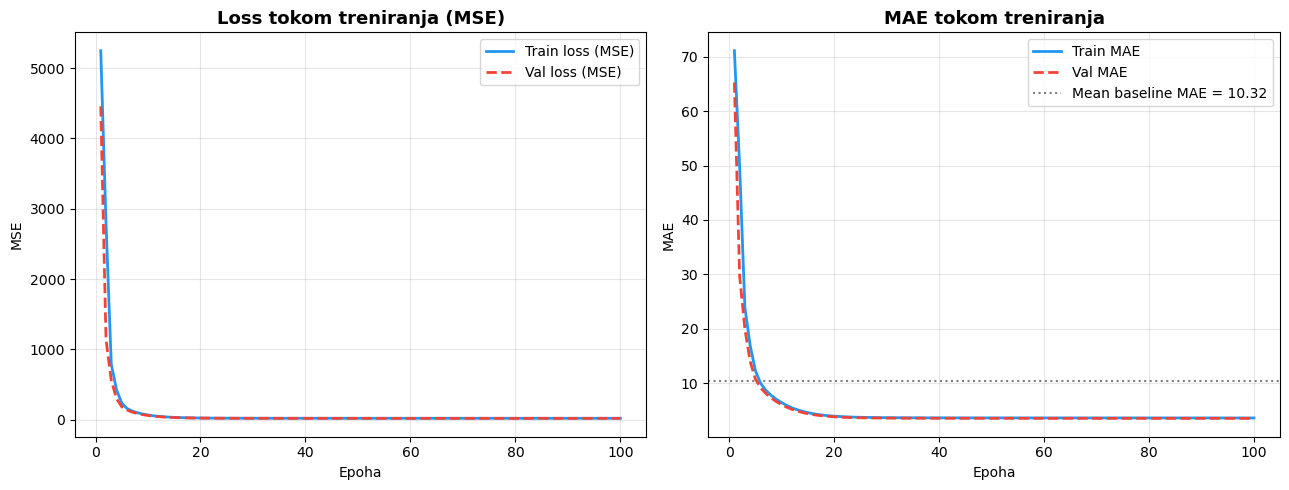

In [316]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history.history['loss']) + 1)

axes[0].plot(epochs_range, history.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history.history['val_loss'],
             label='Val loss (MSE)', color='#F44336', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history.history['val_mae'],
             label='Val MAE', color='#F44336', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline MAE = {mae_baseline:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje:
- Loss kriva
    - Ekstremni pad u prvih 5-10 epoha
    - Mreža brzo uči glavne obrasce a zatim fino podešava
- MAE kriva
    - ima isti obrazac kao Loss kriva (ekstremni pad u prvih 10 epoha)

In [317]:
test_loss, test_mae = baseline_model.evaluate(X_test_s, y_test, verbose=0)
y_pred = baseline_model.predict(X_test_s, verbose=0).flatten()

test_rmse = np.sqrt(test_loss)
test_r2   = r2_score(y_test, y_pred)

eval_df = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Baseline SleepNet': [test_mae, test_rmse, test_r2],
    'Poboljšanje': [mae_baseline - test_mae, rmse_baseline - test_rmse, test_r2 - r2_baseline]
})

print('Evaluacija - Baseline SleepNet (Test set)')
eval_df

Evaluacija - Baseline SleepNet (Test set)


,Metrika,Mean Predictor,Baseline SleepNet,Poboljšanje
0,MAE,10.324915,3.563050,6.761866
1,RMSE,12.955808,4.458980,8.496827
2,R²,-0.000081,0.881538,0.881620


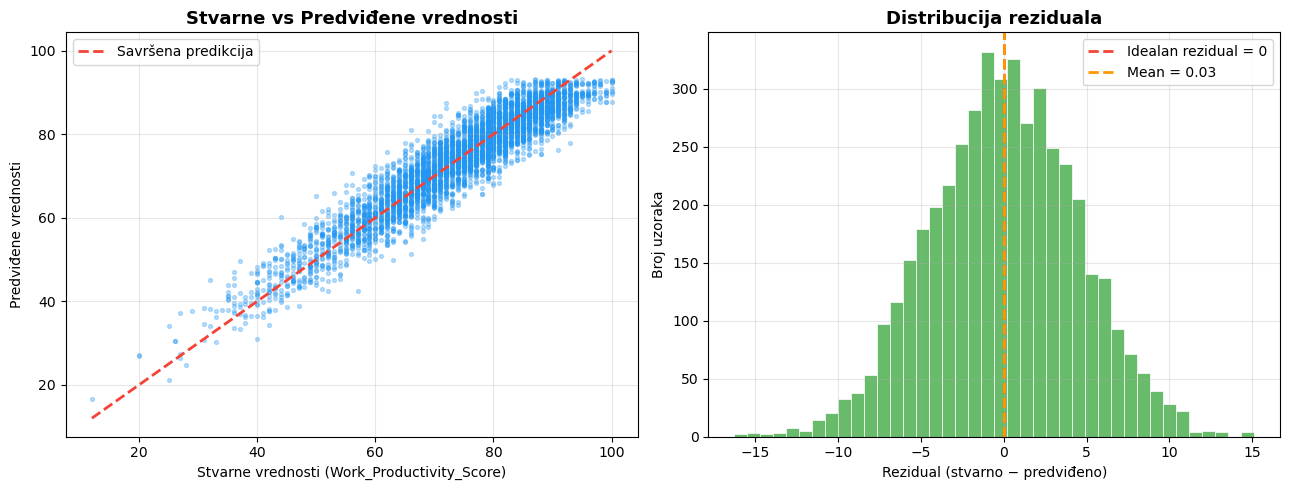

In [318]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals = y_test - y_pred
axes[1].hist(residuals, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals.mean():.2f}')
axes[1].set_title('Distribucija reziduala', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanja:
- Scatter plot
    - Tačke su grupisane oko dijagonale - model dobro predviđa na svim nivoima produktivnosti
    - Malo odstupanje u donjem levom uglu prouzrokovano outlierima
- Distribucija reziduala
    - Simetrična oko nule
    - Model nije pristrasan ni pozitivnoj ni negativnoj strani

## Neuronska mreža sa dubljim slojevima
4 sloja i regularizacione tehnike(L2, Dropout i BatchNormalizatio)

In [319]:
def build_deep_model(input_dim, dropout_rate=0.2, l2_lambda=1e-4):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(
        256, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_1"
    )(inputs)
    x = layers.BatchNormalization(name="bn_1")(x)
    x = layers.Dropout(dropout_rate, name="dropout_1")(x)

    x = layers.Dense(
        128, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_2"
    )(x)
    x = layers.BatchNormalization(name="bn_2")(x)
    x = layers.Dropout(dropout_rate, name="dropout_2")(x)

    x = layers.Dense(
        64, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_3"
    )(x)
    x = layers.BatchNormalization(name="bn_3")(x)
    x = layers.Dropout(dropout_rate / 2, name="dropout_3")(x)

    x = layers.Dense(
        32, activation='relu',
        kernel_regularizer=regularizers.l2(l2_lambda),
        name="dense_4"
    )(x)
    x = layers.BatchNormalization(name="bn_4")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Deep_SleepNet")
    return model

deep_model = build_deep_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in deep_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = deep_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{deep_model.name}"')
summary_df

Model: "Deep_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 256)",2048
2,bn_1,BatchNormalization,"(None, 256)",1024
3,dropout_1,Dropout,"(None, 256)",0
4,dense_2,Dense,"(None, 128)",32896
5,bn_2,BatchNormalization,"(None, 128)",512
6,dropout_2,Dropout,"(None, 128)",0
7,dense_3,Dense,"(None, 64)",8256
8,bn_3,BatchNormalization,"(None, 64)",256
9,dropout_3,Dropout,"(None, 64)",0


In [320]:
deep_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

In [321]:
callbacks_deep = [
    EarlyStopping(
        monitor='val_loss',
        patience=15,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=7,
        min_lr=1e-6,
        verbose=1
    )
]

In [322]:
history_deep = deep_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=150,
    batch_size=256,
    callbacks=callbacks_deep,
    verbose=0
)


Epoch 33: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 40: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 26.


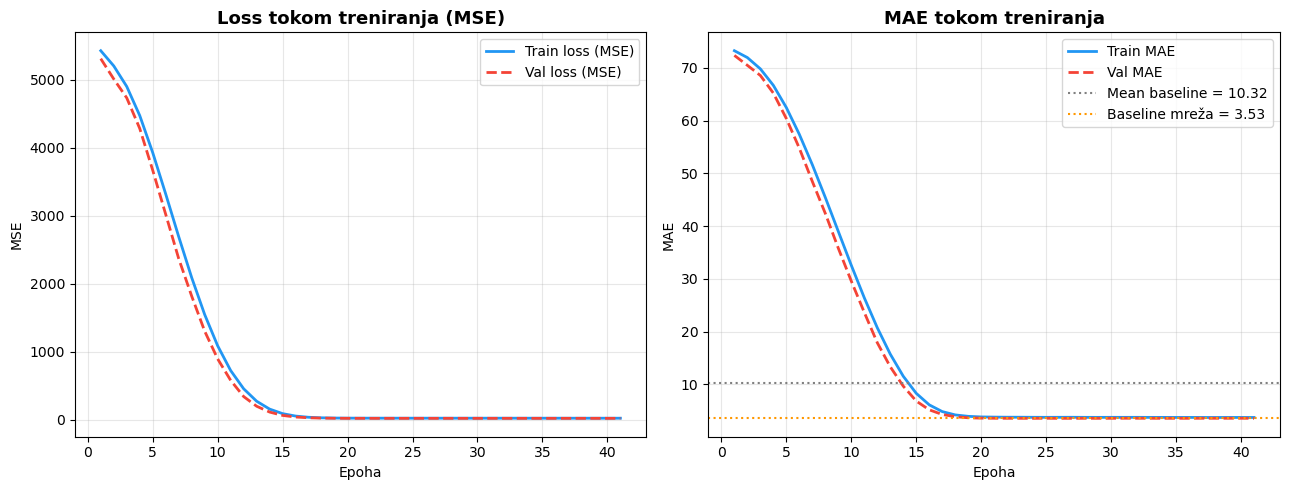

In [323]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_deep.history['loss']) + 1)

axes[0].plot(epochs_range, history_deep.history['loss'],
             label='Train loss (MSE)', color='#2196F3', linewidth=2)
axes[0].plot(epochs_range, history_deep.history['val_loss'],
             label='Val loss (MSE)', color='#F44336',
             linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja (MSE)', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_deep.history['mae'],
             label='Train MAE', color='#2196F3', linewidth=2)
axes[1].plot(epochs_range, history_deep.history['val_mae'],
             label='Val MAE', color='#F44336',
             linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=history.history['val_mae'][-1], color='#FF9800',
                linestyle=':', linewidth=1.5,
                label=f'Baseline mreža = {history.history["val_mae"][-1]:.2f}')
axes[1].set_title('MAE tokom treniranja', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Manje strmoglav od Baseline-a
- Sporiji je po epohama, ali trenira kraće ukupno(manje epoha)

In [324]:
test_loss_f, test_mae_f = deep_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_f = deep_model.predict(X_test_s, verbose=0).flatten()

test_rmse_f = np.sqrt(test_loss_f)
test_r2_f   = r2_score(y_test, y_pred_f)

eval_df = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Baseline SleepNet': [test_mae, test_rmse, test_r2],
    'Deep SleepNet': [test_mae_f, test_rmse_f, test_r2_f],
    'Poboljšanje (Deep vs Baseline)': [test_mae - test_mae_f, test_rmse - test_rmse_f, test_r2_f - test_r2]
})

print('Evaluacija - Deep SleepNet (Test set)')
eval_df

Evaluacija - Deep SleepNet (Test set)


,Metrika,Mean Predictor,Baseline SleepNet,Deep SleepNet,Poboljšanje (Deep vs Baseline)
0,MAE,10.324915,3.563050,3.560146,0.002903
1,RMSE,12.955808,4.458980,4.470133,-0.011153
2,R²,-0.000081,0.881538,0.881159,-0.000380


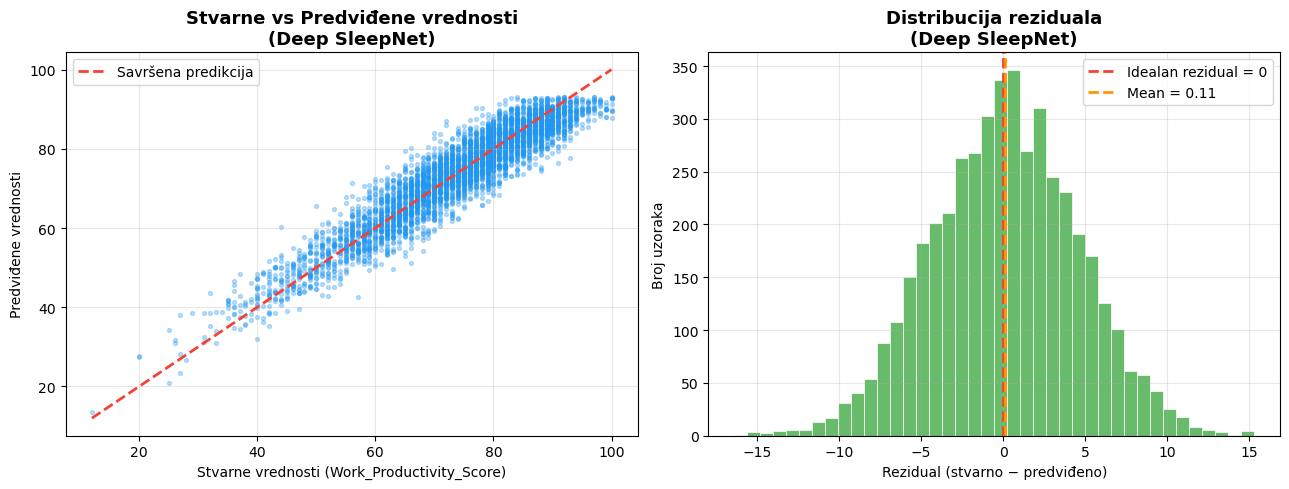

In [325]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_f, alpha=0.3, s=8, color='#2196F3')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2,
             linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Deep SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_f = y_test - y_pred_f
axes[1].hist(residuals_f, bins=40, color='#4CAF50',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_f.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_f.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Deep SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Rezultati deep modela su gori od baseline rezultata.

## Feature engineering
Kombinovano sleep score, stres indikatori, kvardatni termini za nelinearne efekte

In [326]:
dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)

dataset['error_sq']          = dataset['Error_Rate'] ** 2
dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']


In [327]:
eng_features = ['sleep_combined', 'sleep_efficiency', 'stress_index',
                'caffeine_per_hour', 'error_sq', 'energy_mood']
try:
    _ = dataset
    need_load = not all(c in dataset.columns for c in eng_features)
except NameError:
    need_load = True
if need_load:
    dataset = pd.read_csv('Sleep_Patterns_vs_Daily_Performance.csv')
    mood_order = ['Very Bad', 'Bad', 'Neutral', 'Good', 'Excellent']
    mood_map = {m: i for i, m in enumerate(mood_order)}
    dataset['Morning_Mood'] = dataset['Morning_Mood'].map(mood_map)
    if 'sleep_bin' in dataset.columns:
        dataset = dataset.drop(columns=['sleep_bin'])
    dataset['sleep_combined']    = dataset['Sleep_Hours'] * dataset['Sleep_Quality_Score']
    dataset['sleep_efficiency']  = dataset['Sleep_Quality_Score'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['stress_index']      = dataset['Caffeine_Intake_mg'] * dataset['Screen_Time_Before_Bed']
    dataset['caffeine_per_hour'] = dataset['Caffeine_Intake_mg'] / (dataset['Sleep_Hours'] + 1e-6)
    dataset['error_sq']          = dataset['Error_Rate'] ** 2
    dataset['energy_mood']       = dataset['Energy_Level'] * dataset['Morning_Mood']

orig_features = ['Sleep_Hours', 'Sleep_Quality_Score', 'Caffeine_Intake_mg',
                 'Screen_Time_Before_Bed', 'Morning_Mood', 'Error_Rate', 'Energy_Level']

all_cols = orig_features + eng_features
corr_data = []
for col in all_cols:
    r = dataset[col].corr(dataset['Work_Productivity_Score'])
    corr_data.append({
        'Feature': col,
        'Tip': 'originalni' if col in orig_features else 'engineered',
        'Korelacija (r)': round(r, 4)
    })

corr_df = pd.DataFrame(corr_data).sort_values('Korelacija (r)', ascending=False, key=abs)
corr_df.index = range(1, len(corr_df) + 1)

print(f'Korelacija feature-a sa Work_Productivity_Score')
print(f'Originalni: {len(orig_features)} | Engineered: {len(eng_features)} | Ukupno: {len(all_cols)}')
corr_df

Korelacija feature-a sa Work_Productivity_Score
Originalni: 7 | Engineered: 6 | Ukupno: 13


,Feature,Tip,Korelacija (r)
1,Energy_Level,originalni,0.8841
2,Sleep_Quality_Score,originalni,0.8778
3,Error_Rate,originalni,-0.8510
4,error_sq,engineered,-0.8285
5,energy_mood,engineered,0.8028
6,sleep_combined,engineered,0.7807
7,Morning_Mood,originalni,0.7002
8,Sleep_Hours,originalni,0.5524
9,sleep_efficiency,engineered,0.3637
10,Screen_Time_Before_Bed,originalni,-0.3236


### Priprema podataka sa feature-engineered skupom

In [328]:
X_fe = dataset[eng_features].astype(float).values
y_fe = dataset['Work_Productivity_Score'].values.astype(float)

X_fe_train, X_fe_temp, y_fe_train, y_fe_temp = train_test_split(
    X_fe, y_fe, test_size=0.30, random_state=42
)
X_fe_val, X_fe_test, y_fe_val, y_fe_test = train_test_split(
    X_fe_temp, y_fe_temp, test_size=0.50, random_state=42
)

scaler_fe = StandardScaler()
X_fe_train_s = scaler_fe.fit_transform(X_fe_train)
X_fe_val_s   = scaler_fe.transform(X_fe_val)
X_fe_test_s  = scaler_fe.transform(X_fe_test)

print(f"Train:      {X_fe_train_s.shape[0]:,} uzoraka")
print(f"Validation: {X_fe_val_s.shape[0]:,} uzoraka")
print(f"Test:       {X_fe_test_s.shape[0]:,} uzoraka")
print(f"Broj feature-a: {X_fe_train_s.shape[1]}")


Train:      21,000 uzoraka
Validation: 4,500 uzoraka
Test:       4,500 uzoraka
Broj feature-a: 6


### Model: FeatureEng_SleepNet

In [329]:

def build_feature_eng_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(128, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(64,  activation='relu', name="dense_2")(x)
    x = layers.Dense(32,  activation='relu', name="dense_3")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs,
                        name="FeatureEng_SleepNet")
    return model

fe_model = build_feature_eng_model(input_dim=X_fe_train_s.shape[1])

summary_data = []
for layer in fe_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = fe_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{fe_model.name}"')
summary_df


Model: "FeatureEng_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 6)",0
1,dense_1,Dense,"(None, 128)",896
2,dense_2,Dense,"(None, 64)",8256
3,dense_3,Dense,"(None, 32)",2080
4,output,Dense,"(None, 1)",33
5,UKUPNO,,,11265


In [330]:

fe_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_fe = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [331]:

history_fe = fe_model.fit(
    X_fe_train_s, y_fe_train,
    validation_data=(X_fe_val_s, y_fe_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_fe,
    verbose=0
)



Epoch 38: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 44: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Restoring model weights from the end of the best epoch: 100.


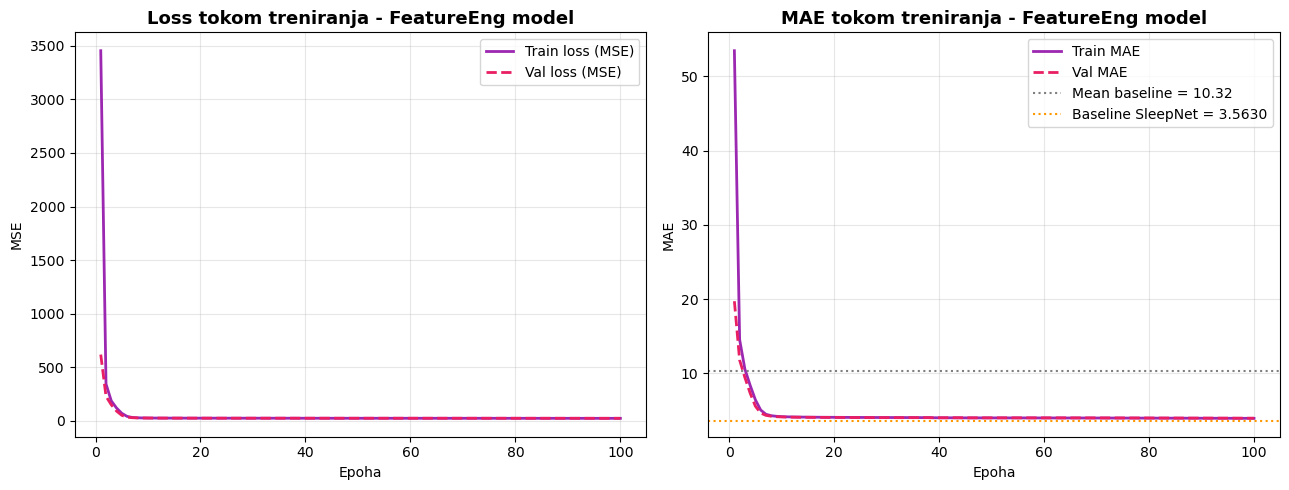

In [332]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_fe.history['loss']) + 1)

axes[0].plot(epochs_range, history_fe.history['loss'],
             label='Train loss (MSE)', color='#9C27B0', linewidth=2)
axes[0].plot(epochs_range, history_fe.history['val_loss'],
             label='Val loss (MSE)', color='#E91E63', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja - FeatureEng model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_fe.history['mae'],
             label='Train MAE', color='#9C27B0', linewidth=2)
axes[1].plot(epochs_range, history_fe.history['val_mae'],
             label='Val MAE', color='#E91E63', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja - FeatureEng model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


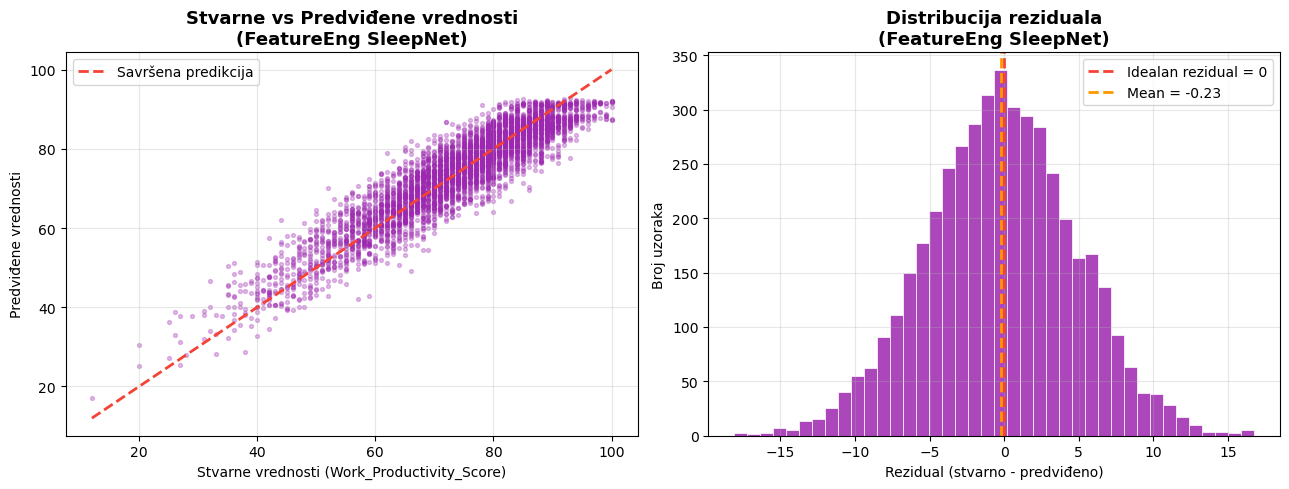

In [333]:

test_loss_fe, test_mae_fe = fe_model.evaluate(X_fe_test_s, y_fe_test, verbose=0)
y_pred_fe = fe_model.predict(X_fe_test_s, verbose=0).flatten()

test_rmse_fe = np.sqrt(test_loss_fe)
test_r2_fe   = r2_score(y_fe_test, y_pred_fe)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_fe_test, y_pred_fe, alpha=0.3, s=8, color='#9C27B0')
axes[0].plot([y_fe_test.min(), y_fe_test.max()],
             [y_fe_test.min(), y_fe_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title(f'Stvarne vs Predviđene vrednosti\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_fe = y_fe_test - y_pred_fe
axes[1].hist(residuals_fe, bins=40, color='#9C27B0',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_fe.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_fe.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(FeatureEng SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno - predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


In [334]:
eval_df = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Baseline SleepNet': [test_mae, test_rmse, test_r2],
    'Deep SleepNet v1': [test_mae_f, test_rmse_f, test_r2_f],
    'FeatureEng SleepNet': [test_mae_fe, test_rmse_fe, test_r2_fe],
    'Poboljšanje (FeatureEng vs Baseline)': [
        test_mae - test_mae_fe,
        test_rmse - test_rmse_fe,
        test_r2_fe - test_r2
    ]
})

print('POREĐENJE SVIH MODELA - Test set (Mean Predictor, Baseline, Deep v1, FeatureEng)')
eval_df


POREĐENJE SVIH MODELA - Test set (Mean Predictor, Baseline, Deep v1, FeatureEng)


,Metrika,Mean Predictor,Baseline SleepNet,Deep SleepNet v1,FeatureEng SleepNet,Poboljšanje (FeatureEng vs Baseline)
0,MAE,10.324915,3.563050,3.560146,3.985680,-0.422631
1,RMSE,12.955808,4.458980,4.470133,5.013950,-0.554970
2,R²,-0.000081,0.881538,0.881159,0.850216,-0.031323


## Residualna mreža

Umesto da se povećava dubina ili širina, uvode se **skip connections** (residualne veze) koje preskaču slojeve.

In [335]:

def build_residual_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, name="projection")(inputs)

    skip1 = x
    x = layers.Dense(64, name="res1_dense1")(x)
    x = layers.BatchNormalization(name="res1_bn1")(x)
    x = layers.Activation('relu', name="res1_relu1")(x)
    x = layers.Dense(64, name="res1_dense2")(x)
    x = layers.BatchNormalization(name="res1_bn2")(x)
    x = layers.Add(name="res1_add")([x, skip1])
    x = layers.Activation('relu', name="res1_out")(x)

    skip2 = x
    x = layers.Dense(64, name="res2_dense1")(x)
    x = layers.BatchNormalization(name="res2_bn1")(x)
    x = layers.Activation('relu', name="res2_relu1")(x)
    x = layers.Dense(64, name="res2_dense2")(x)
    x = layers.BatchNormalization(name="res2_bn2")(x)
    x = layers.Add(name="res2_add")([x, skip2])
    x = layers.Activation('relu', name="res2_out")(x)

    x = layers.Dense(32, activation='relu', name="head")(x)
    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="ResNet_SleepNet")
    return model

resnet_model = build_residual_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in resnet_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = resnet_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{resnet_model.name}"')
summary_df

Model: "ResNet_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,projection,Dense,"(None, 64)",512
2,res1_dense1,Dense,"(None, 64)",4160
3,res1_bn1,BatchNormalization,"(None, 64)",256
4,res1_relu1,Activation,"(None, 64)",0
5,res1_dense2,Dense,"(None, 64)",4160
6,res1_bn2,BatchNormalization,"(None, 64)",256
7,res1_add,Add,"(None, 64)",0
8,res1_out,Activation,"(None, 64)",0
9,res2_dense1,Dense,"(None, 64)",4160


In [336]:

resnet_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_resnet = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [337]:

history_resnet = resnet_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_resnet,
    verbose=0
)


Epoch 36: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 41: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
Epoch 41: early stopping
Restoring model weights from the end of the best epoch: 31.


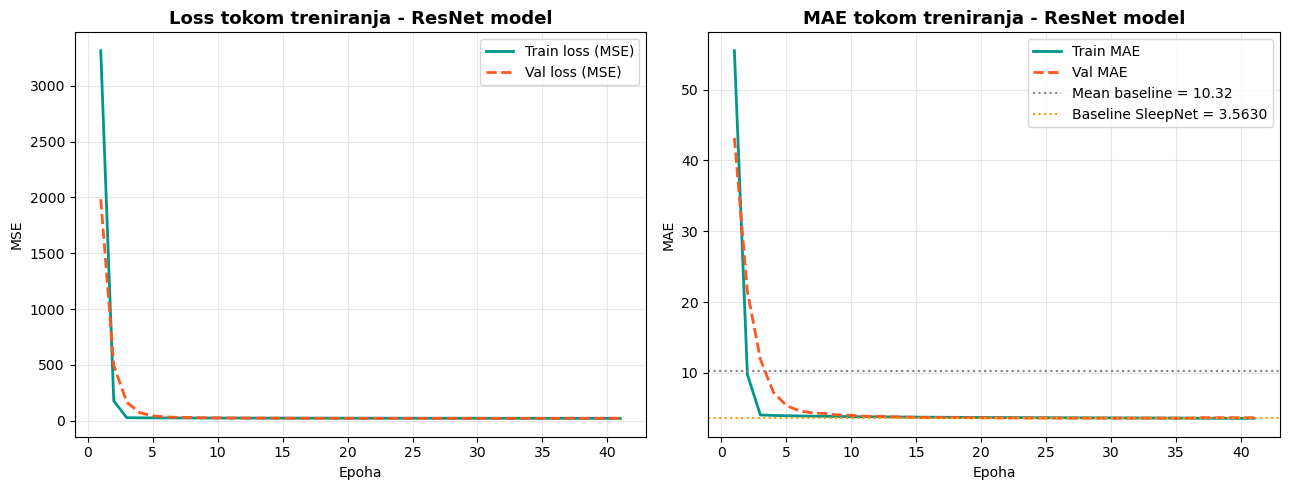

In [338]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_resnet.history['loss']) + 1)

axes[0].plot(epochs_range, history_resnet.history['loss'],
             label='Train loss (MSE)', color='#009688', linewidth=2)
axes[0].plot(epochs_range, history_resnet.history['val_loss'],
             label='Val loss (MSE)', color='#FF5722', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja - ResNet model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_resnet.history['mae'],
             label='Train MAE', color='#009688', linewidth=2)
axes[1].plot(epochs_range, history_resnet.history['val_mae'],
             label='Val MAE', color='#FF5722', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#FF9800', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja - ResNet model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Najstrmoglaviji pad od svih modela - uči za svega približno 5 epoha
- Iako brže uči, finalni MAE ostaje na istom nivou kao Baseline 
- Rezultati nisu poboljšani, ali je postignuto brže treniranje

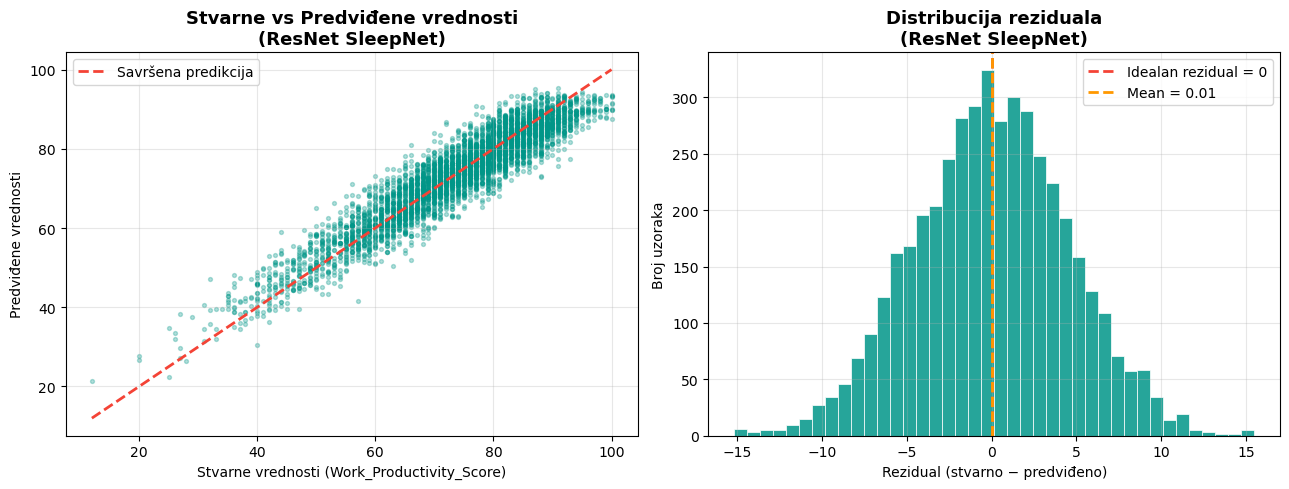

In [339]:
test_loss_res, test_mae_res = resnet_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_res = resnet_model.predict(X_test_s, verbose=0).flatten()

test_rmse_res = np.sqrt(test_loss_res)
test_r2_res   = r2_score(y_test, y_pred_res)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_res, alpha=0.3, s=8, color='#009688')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_res = y_test - y_pred_res
axes[1].hist(residuals_res, bins=40, color='#009688',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_res.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_res.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(ResNet SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno − predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Razlika između rezultata sa Baseline-om nije velika

### Huber loss

Do sada svi modeli koriste **MSE (Mean Squared Error)** kao loss funkciju. 

In [340]:
def build_huber_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="Huber_SleepNet")
    return model

huber_model = build_huber_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in huber_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = huber_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{huber_model.name}"')
summary_df

Model: "Huber_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [341]:

huber_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss=keras.losses.Huber(delta=1.0),
    metrics=['mae']
)

callbacks_huber = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]


In [342]:

history_huber = huber_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=256,
    callbacks=callbacks_huber,
    verbose=0
)


Epoch 67: ReduceLROnPlateau reducing learning rate to 0.0005000000237487257.

Epoch 73: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 79: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.

Epoch 85: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.

Epoch 91: ReduceLROnPlateau reducing learning rate to 3.125000148429535e-05.

Epoch 97: ReduceLROnPlateau reducing learning rate to 1.5625000742147677e-05.
Restoring model weights from the end of the best epoch: 100.


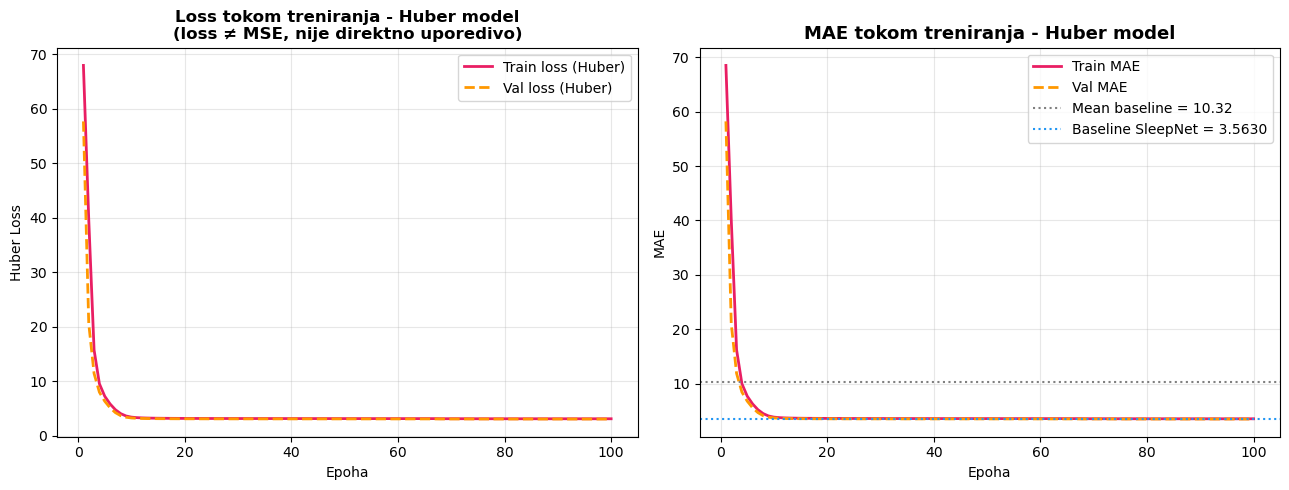

In [343]:

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_huber.history['loss']) + 1)

axes[0].plot(epochs_range, history_huber.history['loss'],
             label='Train loss (Huber)', color='#E91E63', linewidth=2)
axes[0].plot(epochs_range, history_huber.history['val_loss'],
             label='Val loss (Huber)', color='#FF9800', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja - Huber model\n(loss ≠ MSE, nije direktno uporedivo)',
                  fontsize=12, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('Huber Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_huber.history['mae'],
             label='Train MAE', color='#E91E63', linewidth=2)
axes[1].plot(epochs_range, history_huber.history['val_mae'],
             label='Val MAE', color='#FF9800', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].set_title('MAE tokom treniranja - Huber model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


Zapažanje: 
- MAE prolazi ispod Baseline modela negde oko 8 epohe i tu staje
- Minimalno poboljšanje

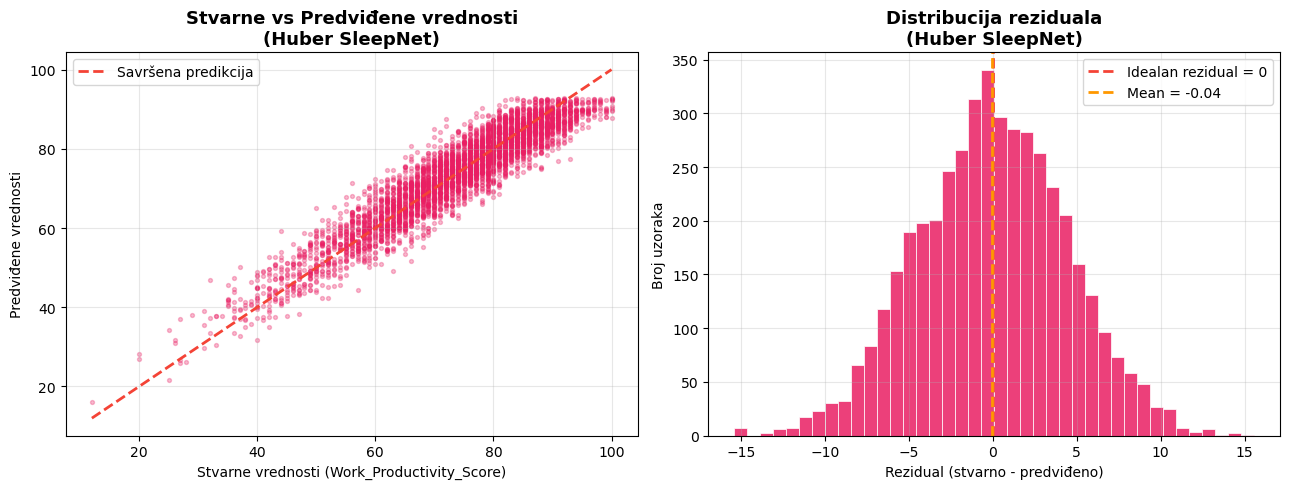

In [344]:
y_pred_huber = huber_model.predict(X_test_s, verbose=0).flatten()

test_mae_huber  = mean_absolute_error(y_test, y_pred_huber)
test_rmse_huber = np.sqrt(mean_squared_error(y_test, y_pred_huber))
test_r2_huber   = r2_score(y_test, y_pred_huber)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_huber, alpha=0.3, s=8, color='#E91E63')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_huber = y_test - y_pred_huber
axes[1].hist(residuals_huber, bins=40, color='#E91E63',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_huber.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_huber.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Huber SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno - predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Skoro identični rezultati kao kod Baseline modela
- Manje kažnjava ekstremne greške, pa se one češće pojavljuju

### Manji batch size + AdamW

In [345]:

def build_adamw_model(input_dim):
    inputs = keras.Input(shape=(input_dim,), name="input")

    x = layers.Dense(64, activation='relu', name="dense_1")(inputs)
    x = layers.Dense(32, activation='relu', name="dense_2")(x)

    outputs = layers.Dense(1, name="output")(x)

    model = keras.Model(inputs=inputs, outputs=outputs, name="AdamW_SleepNet")
    return model

adamw_model = build_adamw_model(input_dim=X_train_s.shape[1])

summary_data = []
for layer in adamw_model.layers:
    summary_data.append({
        'Sloj': layer.name,
        'Tip': layer.__class__.__name__,
        'Izlazni oblik': str(layer.output.shape),
        'Parametri': layer.count_params()
    })

summary_df = pd.DataFrame(summary_data)
total = adamw_model.count_params()
summary_df.loc[len(summary_df)] = ['UKUPNO', '', '', total]

print(f'Model: "{adamw_model.name}"')
summary_df

Model: "AdamW_SleepNet"


,Sloj,Tip,Izlazni oblik,Parametri
0,input,InputLayer,"(None, 7)",0
1,dense_1,Dense,"(None, 64)",512
2,dense_2,Dense,"(None, 32)",2080
3,output,Dense,"(None, 1)",33
4,UKUPNO,,,2625


In [346]:

adamw_model.compile(
    optimizer=keras.optimizers.AdamW(learning_rate=5e-4, weight_decay=1e-5),
    loss='mean_squared_error',
    metrics=['mae']
)

callbacks_adamw = [
    EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True,
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

In [347]:
history_adamw = adamw_model.fit(
    X_train_s, y_train,
    validation_data=(X_val_s, y_val),
    epochs=100,
    batch_size=64,
    callbacks=callbacks_adamw,
    verbose=0
)


Epoch 61: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.

Epoch 67: ReduceLROnPlateau reducing learning rate to 0.0001250000059371814.
Restoring model weights from the end of the best epoch: 98.


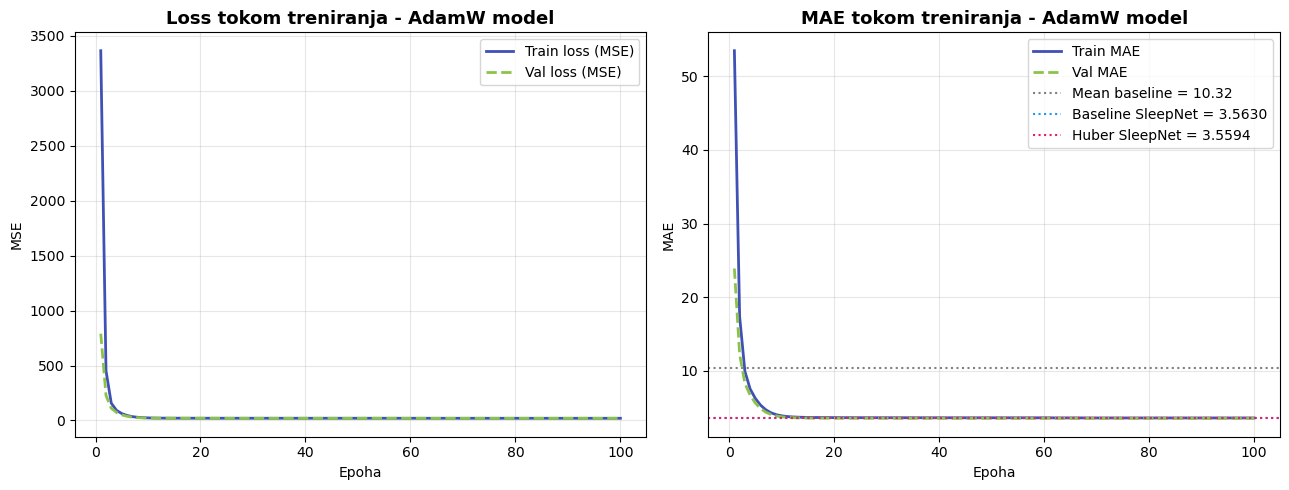

In [348]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
epochs_range = range(1, len(history_adamw.history['loss']) + 1)

axes[0].plot(epochs_range, history_adamw.history['loss'],
             label='Train loss (MSE)', color='#3F51B5', linewidth=2)
axes[0].plot(epochs_range, history_adamw.history['val_loss'],
             label='Val loss (MSE)', color='#8BC34A', linewidth=2, linestyle='--')
axes[0].set_title('Loss tokom treniranja - AdamW model', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Epoha')
axes[0].set_ylabel('MSE')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(epochs_range, history_adamw.history['mae'],
             label='Train MAE', color='#3F51B5', linewidth=2)
axes[1].plot(epochs_range, history_adamw.history['val_mae'],
             label='Val MAE', color='#8BC34A', linewidth=2, linestyle='--')
axes[1].axhline(y=mae_baseline, color='gray', linestyle=':',
                linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1].axhline(y=test_mae, color='#2196F3', linestyle=':',
                linewidth=1.5, label=f'Baseline SleepNet = {test_mae:.4f}')
axes[1].axhline(y=test_mae_huber, color='#E91E63', linestyle=':',
                linewidth=1.5, label=f'Huber SleepNet = {test_mae_huber:.4f}')
axes[1].set_title('MAE tokom treniranja - AdamW model', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Epoha')
axes[1].set_ylabel('MAE')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Najbrže uči u odnosu na sve ostale modele (približno 3-4 epohe)
- MAE prolazi ispod Baseline 

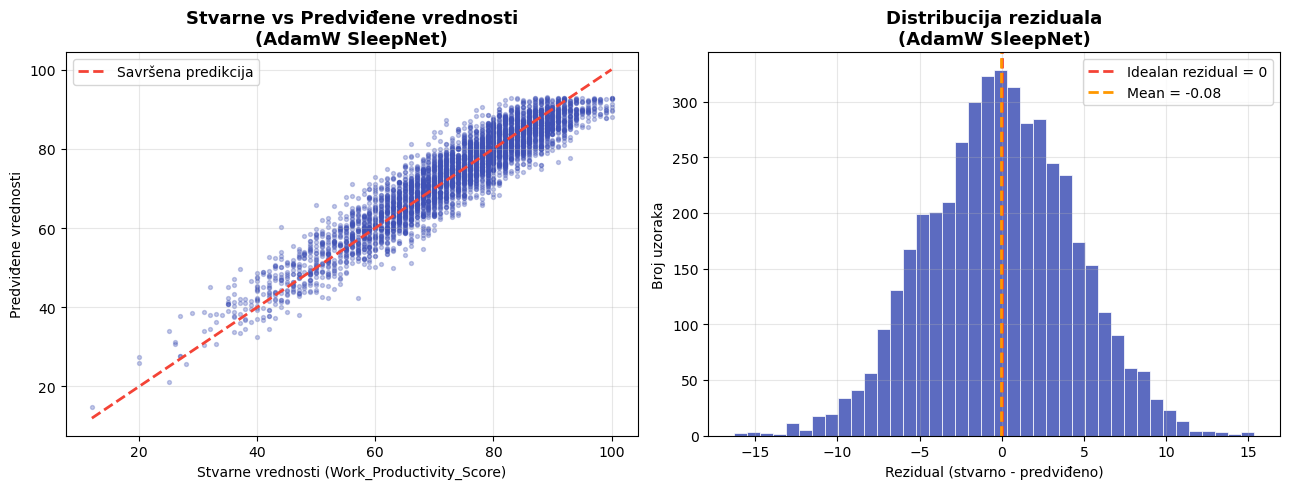

In [349]:
test_loss_adamw, test_mae_adamw = adamw_model.evaluate(X_test_s, y_test, verbose=0)
y_pred_adamw = adamw_model.predict(X_test_s, verbose=0).flatten()

test_rmse_adamw = np.sqrt(test_loss_adamw)
test_r2_adamw   = r2_score(y_test, y_pred_adamw)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_adamw, alpha=0.3, s=8, color='#3F51B5')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title('Stvarne vs Predviđene vrednosti\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_adamw = y_test - y_pred_adamw
axes[1].hist(residuals_adamw, bins=40, color='#3F51B5',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_adamw.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_adamw.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(AdamW SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno - predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Scatter plot
    - Raspored sličan Baseline modelu, bez vidljivog poboljšanja rasipanja
- Distribucija reziduala
    - Reziduali su simetrično raspoređeni oko nule

In [350]:
print('Evaluacija - AdamW SleepNet (Test set)')

eval_df_adamw = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'AdamW SleepNet': [test_mae_adamw, test_rmse_adamw, test_r2_adamw],
    'Poboljšanje': [mae_baseline - test_mae_adamw,
                   rmse_baseline - test_rmse_adamw,
                   test_r2_adamw - r2_baseline]
})

eval_df_adamw

Evaluacija - AdamW SleepNet (Test set)


,Metrika,Mean Predictor,AdamW SleepNet,Poboljšanje
0,MAE,10.324915,3.557094,6.767821
1,RMSE,12.955808,4.453091,8.502717
2,R²,-0.000081,0.881851,0.881932


## Ensemble

Umesto jednog modela, trenira se **5 identičnih modela sa različitim random seedovima** i kombinuju se njihove predikcije.

In [351]:
SEEDS        = [0, 7, 42, 123, 999]
ensemble_preds_val  = []
ensemble_preds_test = []
ensemble_histories  = []
rows = []

for i, seed in enumerate(SEEDS):

    np.random.seed(seed)
    tf.random.set_seed(seed)

    m = keras.Sequential([
        keras.Input(shape=(X_train_s.shape[1],)),
        layers.Dense(64, activation='relu'),
        layers.Dense(32, activation='relu'),
        layers.Dense(1)
    ], name=f"ensemble_model_{i+1}")

    m.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss=keras.losses.Huber(delta=1.0),
        metrics=['mae']
    )

    cb = [
        EarlyStopping(monitor='val_loss', patience=10,
                      restore_best_weights=True, verbose=0),
        ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                          patience=5, min_lr=1e-6, verbose=0)
    ]

    hist = m.fit(
        X_train_s, y_train,
        validation_data=(X_val_s, y_val),
        epochs=100,
        batch_size=256,
        callbacks=cb,
        verbose=0
    )

    val_pred  = m.predict(X_val_s,  verbose=0).flatten()
    test_pred = m.predict(X_test_s, verbose=0).flatten()

    val_mae_i  = mean_absolute_error(y_val,  val_pred)
    test_mae_i = mean_absolute_error(y_test, test_pred)

    ensemble_preds_val.append(val_pred)
    ensemble_preds_test.append(test_pred)
    ensemble_histories.append(hist)

    n_epochs = len(hist.history['loss'])
    rows.append({
        "Model": i + 1,
        "Seed": seed,
        "Epohe": n_epochs,
        "Val MAE": val_mae_i,
        "Test MAE": test_mae_i
    })

    print(f"  Epohe: {n_epochs:>3}  |  "
          f"Val MAE: {val_mae_i:.4f}  |  Test MAE: {test_mae_i:.4f}")

df_results = pd.DataFrame(rows)
display(df_results.style.format({"Val MAE": "{:.4f}", "Test MAE": "{:.4f}"}))

  Epohe:  61  |  Val MAE: 3.5342  |  Test MAE: 3.5655
  Epohe:  96  |  Val MAE: 3.5449  |  Test MAE: 3.5703
  Epohe: 100  |  Val MAE: 3.5406  |  Test MAE: 3.5676
  Epohe:  86  |  Val MAE: 3.5340  |  Test MAE: 3.5592
  Epohe:  62  |  Val MAE: 3.5301  |  Test MAE: 3.5677


,Model,Seed,Epohe,Val MAE,Test MAE
0,1,0,61,3.5342,3.5655
1,2,7,96,3.5449,3.5703
2,3,42,100,3.5406,3.5676
3,4,123,86,3.5340,3.5592
4,5,999,62,3.5301,3.5677


In [352]:
y_pred_ensemble = np.mean(ensemble_preds_test, axis=0)

test_mae_ensemble  = mean_absolute_error(y_test, y_pred_ensemble)
test_rmse_ensemble = np.sqrt(mean_squared_error(y_test, y_pred_ensemble))
test_r2_ensemble   = r2_score(y_test, y_pred_ensemble)

rows_eval = []
for i, (seed, hist, test_pred) in enumerate(
        zip(SEEDS, ensemble_histories, ensemble_preds_test)):
    vm = mean_absolute_error(y_val, ensemble_preds_val[i])
    tm = mean_absolute_error(y_test, test_pred)
    rows_eval.append({
        "Model": f"Seed {seed} (m{i+1})",
        "Val MAE": vm,
        "Test MAE": tm
    })

rows_eval.append({
    "Model": "ENSEMBLE",
    "Val MAE": np.nan,
    "Test MAE": test_mae_ensemble
})

df_eval = pd.DataFrame(rows_eval)
display(df_eval.style.format({"Val MAE": "{:.4f}", "Test MAE": "{:.4f}"}, na_rep="-"))

improvement_rows = [
    {
        "Metrika": "MAE",
        "Razlika": test_mae_huber - test_mae_ensemble,
        "%": (test_mae_huber - test_mae_ensemble) / test_mae_huber * 100
    },
    {
        "Metrika": "RMSE",
        "Razlika": test_rmse_huber - test_rmse_ensemble,
        "%": (test_rmse_huber - test_rmse_ensemble) / test_rmse_huber * 100
    },
    {
        "Metrika": "R2",
        "Razlika": test_r2_ensemble - test_r2_huber,
        "%": np.nan
    }
]

df_improvement = pd.DataFrame(improvement_rows)
print("\nPoboljsanje ensemble vs best single (Huber):")
display(df_improvement.style.format({"Razlika": "{:+.4f}", "%": "{:+.2f}%"}, na_rep="-"))

,Model,Val MAE,Test MAE
0,Seed 0 (m1),3.5342,3.5655
1,Seed 7 (m2),3.5449,3.5703
2,Seed 42 (m3),3.5406,3.5676
3,Seed 123 (m4),3.5340,3.5592
4,Seed 999 (m5),3.5301,3.5677
5,ENSEMBLE,-,3.5577



Poboljsanje ensemble vs best single (Huber):


,Metrika,Razlika,%
0,MAE,+0.0016,+0.05%
1,RMSE,+0.0077,+0.17%
2,R2,+0.0004,-


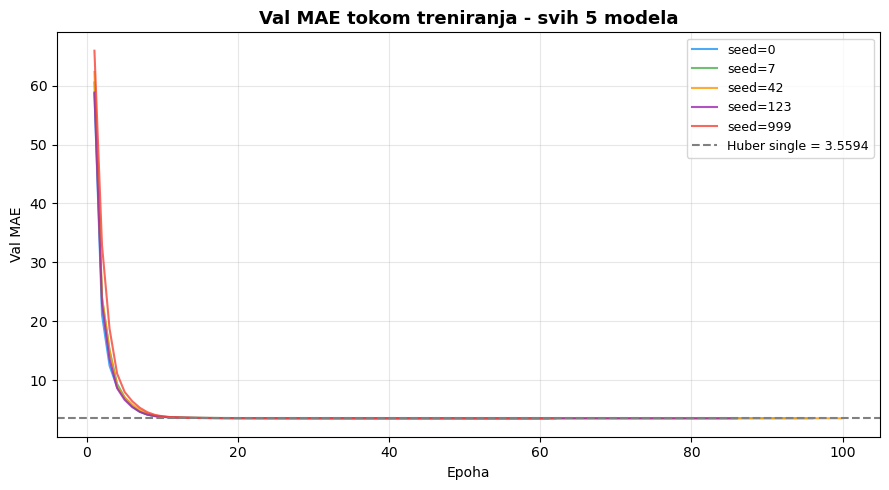

In [353]:
fig, ax = plt.subplots(1, 1, figsize=(9, 5))

colors_ens = ['#2196F3', '#4CAF50', '#FF9800', '#9C27B0', '#F44336']
for i, (hist, seed) in enumerate(zip(ensemble_histories, SEEDS)):
    ep = range(1, len(hist.history['val_mae']) + 1)
    ax.plot(ep, hist.history['val_mae'],
            color=colors_ens[i], linewidth=1.5,
            alpha=0.8, label=f'seed={seed}')
ax.axhline(y=test_mae_huber, color='gray', linestyle='--',
           linewidth=1.5, label=f'Huber single = {test_mae_huber:.4f}')
ax.set_title('Val MAE tokom treniranja - svih 5 modela', fontsize=13, fontweight='bold')
ax.set_xlabel('Epoha')
ax.set_ylabel('Val MAE')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Val MAE krive svih 5 modela su veoma slične - varijabilnost zbog različitih seedova je mala
- Ensemble kombinovanjem proseka 5 modela postiže stabilnije predikcije od jednog modela

In [354]:
eval_df_ensemble = pd.DataFrame({
    'Metrika': ['MAE', 'RMSE', 'R²'],
    'Mean Predictor': [mae_baseline, rmse_baseline, r2_baseline],
    'Huber SleepNet': [test_mae_huber, test_rmse_huber, test_r2_huber],
    'Ensemble SleepNet (x5)': [test_mae_ensemble, test_rmse_ensemble, test_r2_ensemble],
    'Poboljšanje (Ensemble vs Huber)': [
        test_mae_huber - test_mae_ensemble,
        test_rmse_huber - test_rmse_ensemble,
        test_r2_ensemble - test_r2_huber
    ]
})

print('Evaluacija - Ensemble SleepNet (Test set)')
eval_df_ensemble

Evaluacija - Ensemble SleepNet (Test set)


,Metrika,Mean Predictor,Huber SleepNet,Ensemble SleepNet (x5),Poboljšanje (Ensemble vs Huber)
0,MAE,10.324915,3.559375,3.557742,0.001633
1,RMSE,12.955808,4.460062,4.452391,0.007671
2,R²,-0.000081,0.881481,0.881888,0.000407


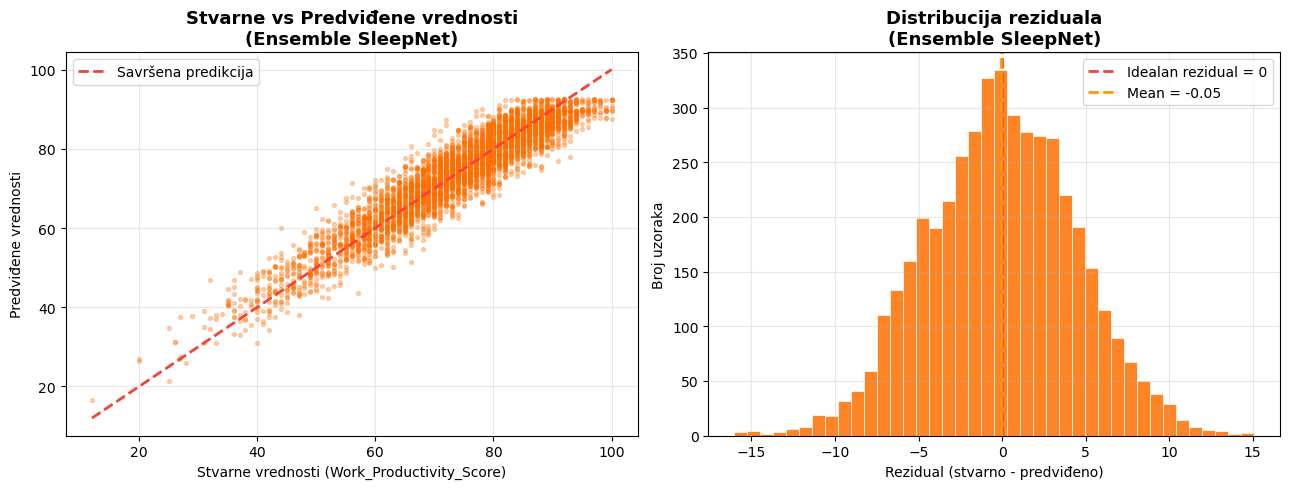

In [355]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, y_pred_ensemble, alpha=0.3, s=8, color='#FF6F00')
axes[0].plot([y_test.min(), y_test.max()],
             [y_test.min(), y_test.max()],
             color='#F44336', linewidth=2, linestyle='--', label='Savršena predikcija')
axes[0].set_title(f'Stvarne vs Predviđene vrednosti\n(Ensemble SleepNet)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('Stvarne vrednosti (Work_Productivity_Score)')
axes[0].set_ylabel('Predviđene vrednosti')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

residuals_ens = y_test - y_pred_ensemble
axes[1].hist(residuals_ens, bins=40, color='#FF6F00',
             edgecolor='white', linewidth=0.6, alpha=0.85)
axes[1].axvline(x=0, color='#F44336', linewidth=2,
                linestyle='--', label='Idealan rezidual = 0')
axes[1].axvline(x=residuals_ens.mean(), color='#FF9800', linewidth=2,
                linestyle='--', label=f'Mean = {residuals_ens.mean():.2f}')
axes[1].set_title('Distribucija reziduala\n(Ensemble SleepNet)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Rezidual (stvarno - predviđeno)')
axes[1].set_ylabel('Broj uzoraka')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Zapažanje: 
- Scatter plot pokazuje tačke grupisane oko dijagonale slično kao kod Huber modela
- Reziduali su simetrično raspoređeni i bez sistematske greške

In [356]:

rows_models = [
    {
        "Model": "Mean Predictor",
        "MAE": mae_baseline,
        "RMSE": rmse_baseline,
        "R2": r2_baseline,
        "Epohe": np.nan,
        "Loss": "-",
        "Batch": "-"
    },
    {
        "Model": "Baseline SleepNet",
        "MAE": test_mae,
        "RMSE": test_rmse,
        "R2": test_r2,
        "Epohe": len(history.history['loss']),
        "Loss": "MSE",
        "Batch": 256
    },
    {
        "Model": "Deep SleepNet v1",
        "MAE": test_mae_f,
        "RMSE": test_rmse_f,
        "R2": test_r2_f,
        "Epohe": len(history_deep.history['loss']),
        "Loss": "MSE",
        "Batch": 256
    },
    {
        "Model": "ResNet SleepNet",
        "MAE": test_mae_res,
        "RMSE": test_rmse_res,
        "R2": test_r2_res,
        "Epohe": len(history_resnet.history['loss']),
        "Loss": "MSE",
        "Batch": 256
    },
    {
        "Model": "Huber SleepNet",
        "MAE": test_mae_huber,
        "RMSE": test_rmse_huber,
        "R2": test_r2_huber,
        "Epohe": len(history_huber.history['loss']),
        "Loss": "Huber",
        "Batch": 256
    },
    {
        "Model": "AdamW SleepNet",
        "MAE": test_mae_adamw,
        "RMSE": test_rmse_adamw,
        "R2": test_r2_adamw,
        "Epohe": len(history_adamw.history['loss']),
        "Loss": "MSE",
        "Batch": 64
    },
    {
        "Model": "Ensemble SleepNet (x5)",
        "MAE": test_mae_ensemble,
        "RMSE": test_rmse_ensemble,
        "R2": test_r2_ensemble,
        "Epohe": "5x~",
        "Loss": "Huber",
        "Batch": 256
    }
]

df_models = pd.DataFrame(rows_models)
print("POREDJENJE SVIH MODELA - Test set")
display(
    df_models.style.format({"MAE": "{:.4f}", "RMSE": "{:.4f}", "R2": "{:.4f}"}, na_rep="-")
)

all_maes = {
    "Baseline SleepNet": test_mae,
    "Deep SleepNet v1": test_mae_f,
    "ResNet SleepNet": test_mae_res,
    "Huber SleepNet": test_mae_huber,
    "AdamW SleepNet": test_mae_adamw,
    "Ensemble SleepNet": test_mae_ensemble,
}
best_name = min(all_maes, key=all_maes.get)
best_val = all_maes[best_name]

summary_rows = [
    {
        "Najbolji model": best_name,
        "Najbolji MAE": best_val,
        "Poboljsanje vs Baseline": test_mae - best_val,
        "%": (test_mae - best_val) / test_mae * 100,
    }
]
df_summary = pd.DataFrame(summary_rows)
display(df_summary.style.format({"Najbolji MAE": "{:.4f}", "Poboljsanje vs Baseline": "{:+.4f}", "%": "{:+.2f}%"}))


POREDJENJE SVIH MODELA - Test set


,Model,MAE,RMSE,R2,Epohe,Loss,Batch
0,Mean Predictor,10.3249,12.9558,-0.0001,-,-,-
1,Baseline SleepNet,3.5630,4.4590,0.8815,100,MSE,256
2,Deep SleepNet v1,3.5601,4.4701,0.8812,41,MSE,256
3,ResNet SleepNet,3.6227,4.5413,0.8771,41,MSE,256
4,Huber SleepNet,3.5594,4.4601,0.8815,100,Huber,256
5,AdamW SleepNet,3.5571,4.4531,0.8819,100,MSE,64
6,Ensemble SleepNet (x5),3.5577,4.4524,0.8819,5x~,Huber,256


,Najbolji model,Najbolji MAE,Poboljsanje vs Baseline,%
0,AdamW SleepNet,3.5571,+0.0060,+0.17%


## PyTorch
Implementiraju se dva modela:
1. *PyTorch Baseline* - arhitektura identična Baseline SleepNet arhitekturi
2. *PyTorch Huber* - Huber loss funkcija

In [357]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
 
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
 
X_train_t = torch.tensor(X_train_s, dtype=torch.float32).to(device)
y_train_t = torch.tensor(y_train,   dtype=torch.float32).unsqueeze(1).to(device)
X_val_t   = torch.tensor(X_val_s,   dtype=torch.float32).to(device)
y_val_t   = torch.tensor(y_val,     dtype=torch.float32).unsqueeze(1).to(device)
X_test_t  = torch.tensor(X_test_s,  dtype=torch.float32).to(device)
y_test_t  = torch.tensor(y_test,    dtype=torch.float32).unsqueeze(1).to(device)
train_ds     = TensorDataset(X_train_t, y_train_t)
train_loader = DataLoader(train_ds, batch_size=256, shuffle=True)
 
print(f'Train tenzor: {X_train_t.shape}')
print(f'Val tenzor:   {X_val_t.shape}')
print(f'Test tenzor:  {X_test_t.shape}')

Train tenzor: torch.Size([21000, 7])
Val tenzor:   torch.Size([4500, 7])
Test tenzor:  torch.Size([4500, 7])


In [358]:
class SleepNetPyTorch(nn.Module):
    def __init__(self, input_dim):
        super(SleepNetPyTorch, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 1)
        )
 
    def forward(self, x):
        return self.network(x)
 
 
input_dim = X_train_s.shape[1]
pt_model  = SleepNetPyTorch(input_dim).to(device)
 
print(pt_model)
print()
total_params     = sum(p.numel() for p in pt_model.parameters())
trainable_params = sum(p.numel() for p in pt_model.parameters() if p.requires_grad)

SleepNetPyTorch(
  (network): Sequential(
    (0): Linear(in_features=7, out_features=64, bias=True)
    (1): ReLU()
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ReLU()
    (4): Linear(in_features=32, out_features=1, bias=True)
  )
)



In [359]:
def train_pytorch_model(model, train_loader, X_val, y_val,
                        criterion, optimizer, scheduler,
                        max_epochs=100, patience=10, verbose=True):
    history = {'train_loss': [], 'val_loss': [], 'train_mae': [], 'val_mae': []}
    best_val_loss   = float('inf')
    best_weights    = None
    patience_counter = 0
    mae_fn = nn.L1Loss()
 
    for epoch in range(1, max_epochs + 1):
        model.train()
        epoch_loss, epoch_mae, n_batches = 0.0, 0.0, 0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
            epoch_mae  += mae_fn(preds, y_batch).item()
            n_batches  += 1
        train_loss = epoch_loss / n_batches
        train_mae  = epoch_mae  / n_batches
 
        model.eval()
        with torch.no_grad():
            val_preds = model(X_val)
            val_loss  = criterion(val_preds, y_val).item()
            val_mae   = mae_fn(val_preds, y_val).item()
 
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['train_mae'].append(train_mae)
        history['val_mae'].append(val_mae)
 
        scheduler.step(val_loss)
 
        if val_loss < best_val_loss:
            best_val_loss    = val_loss
            best_weights     = {k: v.clone() for k, v in model.state_dict().items()}
            patience_counter = 0
        else:
            patience_counter += 1
            if patience_counter >= patience:
                if verbose:
                    print(f'EarlyStopping u epohi {epoch} (best val_loss={best_val_loss:.4f})')
                break
 
        if verbose and epoch % 20 == 0:
            lr = optimizer.param_groups[0]['lr']
            print(f'Epoha {epoch:>3}/{max_epochs}  '
                  f'train_loss={train_loss:.4f}  val_loss={val_loss:.4f}  '
                  f'val_mae={val_mae:.4f}  lr={lr:.2e}')
 
    model.load_state_dict(best_weights)
    return history

### PyTorch Baseline

In [360]:
torch.manual_seed(42)
 
pt_baseline = SleepNetPyTorch(input_dim).to(device)
 
criterion_mse  = nn.MSELoss()
optimizer_pt   = optim.Adam(pt_baseline.parameters(), lr=1e-3)
scheduler_pt   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_pt, mode='min', factor=0.5, patience=5, min_lr=1e-6
)
 
print('Treniranje PyTorch Baseline (MSE)...')
history_pt_baseline = train_pytorch_model(
    pt_baseline, train_loader, X_val_t, y_val_t,
    criterion_mse, optimizer_pt, scheduler_pt,
    max_epochs=100, patience=10, verbose=True
)
 
print(f'\nUkupno epoha: {len(history_pt_baseline["train_loss"])}')
print(f'Finalna val MAE: {history_pt_baseline["val_mae"][-1]:.4f}')
 

Treniranje PyTorch Baseline (MSE)...
Epoha  20/100  train_loss=22.1839  val_loss=21.1224  val_mae=3.6632  lr=1.00e-03
Epoha  40/100  train_loss=20.5872  val_loss=19.8489  val_mae=3.5515  lr=5.00e-04
Epoha  60/100  train_loss=20.4497  val_loss=19.7281  val_mae=3.5419  lr=2.50e-04
EarlyStopping u epohi 69 (best val_loss=19.6850)

Ukupno epoha: 69
Finalna val MAE: 3.5406


In [361]:
pt_baseline.eval()
with torch.no_grad():
    y_pred_pt_baseline = pt_baseline(X_test_t).cpu().numpy().flatten()
 
pt_base_mae  = mean_absolute_error(y_test, y_pred_pt_baseline)
pt_base_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pt_baseline))
pt_base_r2   = r2_score(y_test, y_pred_pt_baseline)
 
print('PyTorch Baseline - Test set:')
print(f'  MAE:  {pt_base_mae:.4f}  (Keras baseline: {test_mae:.4f})')
print(f'  RMSE: {pt_base_rmse:.4f}  (Keras baseline: {test_rmse:.4f})')
print(f'  R²:   {pt_base_r2:.4f}   (Keras baseline: {test_r2:.4f})')

PyTorch Baseline - Test set:
  MAE:  3.5618  (Keras baseline: 3.5630)
  RMSE: 4.4621  (Keras baseline: 4.4590)
  R²:   0.8814   (Keras baseline: 0.8815)


### PyTorch Huber model

In [362]:
torch.manual_seed(42)
 
pt_baseline.eval()
with torch.no_grad():
    y_val_pt_pred_base = pt_baseline(X_val_t).cpu().numpy().flatten()
abs_errors_val  = np.abs(y_val - y_val_pt_pred_base)
 
delta_opt = float(np.percentile(abs_errors_val, 75))
 
pt_huber = SleepNetPyTorch(input_dim).to(device)
 
criterion_huber = nn.HuberLoss(delta=delta_opt)
optimizer_pth   = optim.Adam(pt_huber.parameters(), lr=1e-3)
scheduler_pth   = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_pth, mode='min', factor=0.5, patience=5, min_lr=1e-6
)
print(f'Treniranje PyTorch Huber modela (delta={delta_opt:.4f})...')
history_pt_huber = train_pytorch_model(
    pt_huber, train_loader, X_val_t, y_val_t,
    criterion_huber, optimizer_pth, scheduler_pth,
    max_epochs=100, patience=10, verbose=True
)
 
print(f'\nUkupno epoha: {len(history_pt_huber["train_loss"])}')
print(f'Finalna val MAE: {history_pt_huber["val_mae"][-1]:.4f}')

Treniranje PyTorch Huber modela (delta=5.0780)...
Epoha  20/100  train_loss=9.1709  val_loss=8.9726  val_mae=3.5829  lr=1.00e-03
Epoha  40/100  train_loss=9.0532  val_loss=8.8020  val_mae=3.5520  lr=5.00e-04
EarlyStopping u epohi 53 (best val_loss=8.7325)

Ukupno epoha: 53
Finalna val MAE: 3.5359


In [363]:
pt_huber.eval()
with torch.no_grad():
    y_pred_pt_huber = pt_huber(X_test_t).cpu().numpy().flatten()
 
pt_huber_mae  = mean_absolute_error(y_test, y_pred_pt_huber)
pt_huber_rmse = np.sqrt(mean_squared_error(y_test, y_pred_pt_huber))
pt_huber_r2   = r2_score(y_test, y_pred_pt_huber)
 
print('PyTorch Huber - Test set:')
print(f'  MAE:  {pt_huber_mae:.4f}  (Keras Huber: {test_mae_huber:.4f})')
print(f'  RMSE: {pt_huber_rmse:.4f}  (Keras Huber: {test_rmse_huber:.4f})')
print(f'  R²:   {pt_huber_r2:.4f}   (Keras Huber: {test_r2_huber:.4f})')

PyTorch Huber - Test set:
  MAE:  3.5576  (Keras Huber: 3.5594)
  RMSE: 4.4515  (Keras Huber: 4.4601)
  R²:   0.8819   (Keras Huber: 0.8815)


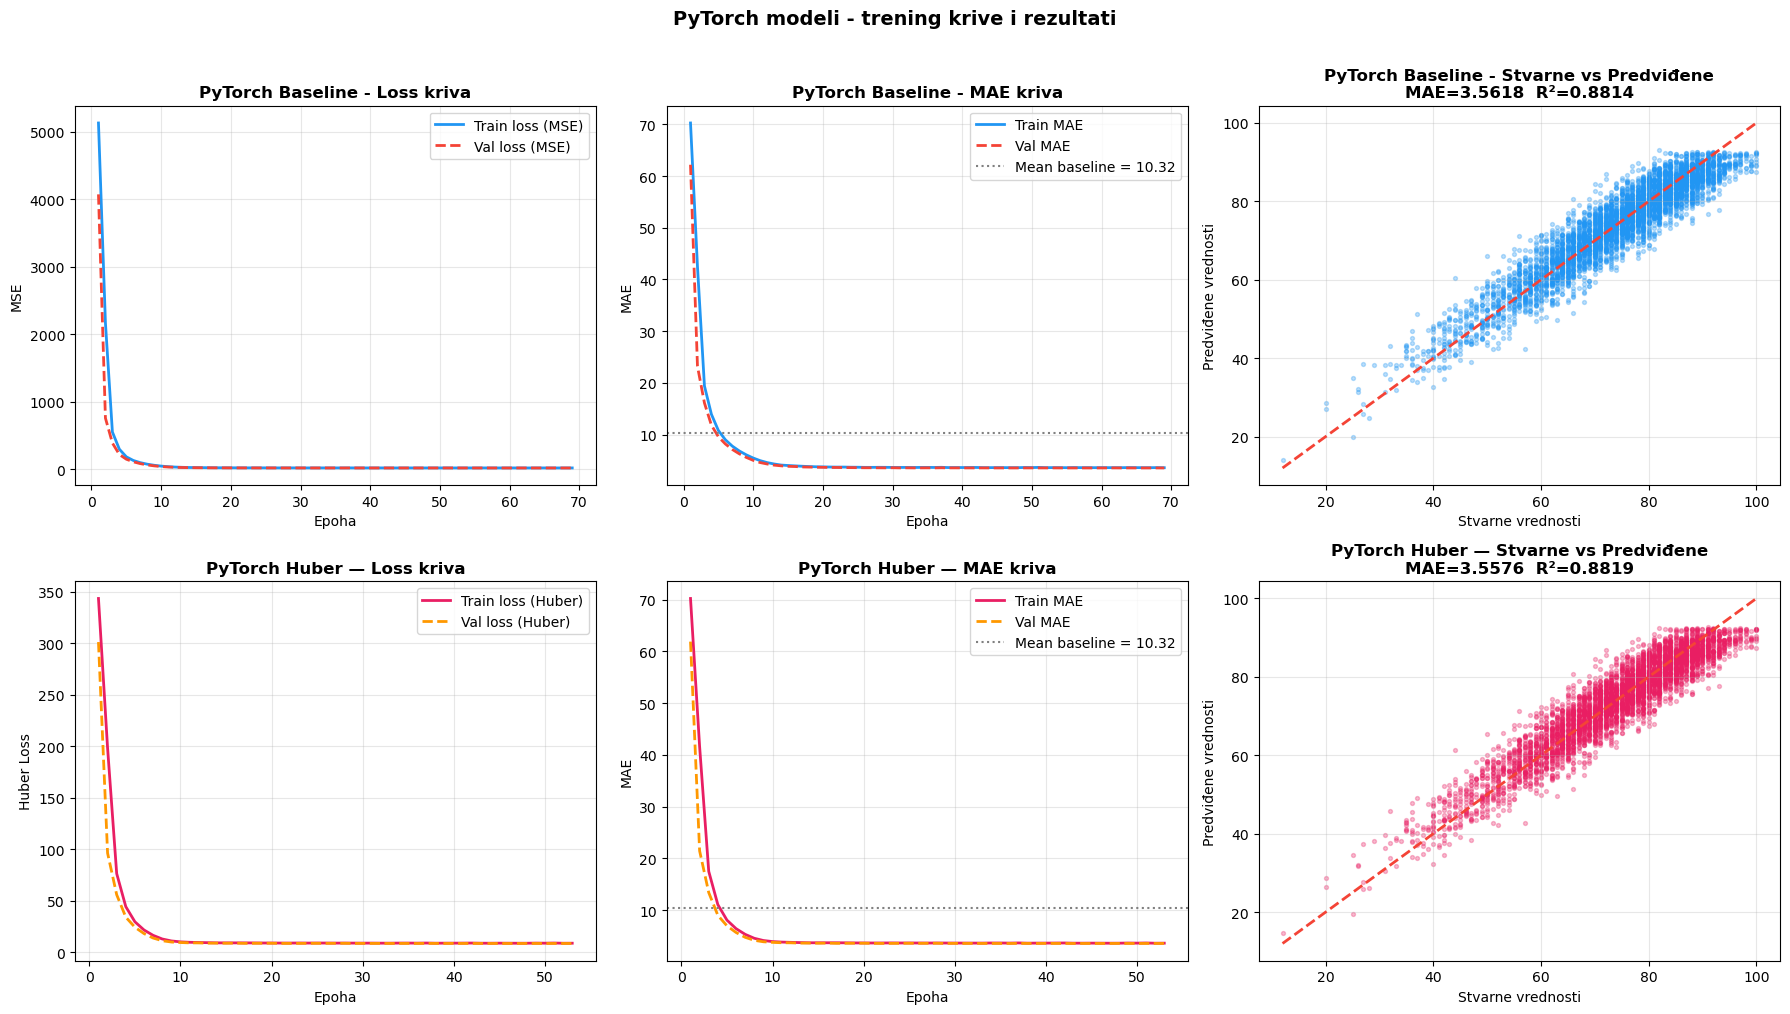

In [364]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
 
ep_base = range(1, len(history_pt_baseline['train_loss']) + 1)
axes[0,0].plot(ep_base, history_pt_baseline['train_loss'],
               color='#2196F3', linewidth=2, label='Train loss (MSE)')
axes[0,0].plot(ep_base, history_pt_baseline['val_loss'],
               color='#F44336', linewidth=2, linestyle='--', label='Val loss (MSE)')
axes[0,0].set_title('PyTorch Baseline - Loss kriva', fontsize=12, fontweight='bold')
axes[0,0].set_xlabel('Epoha'); axes[0,0].set_ylabel('MSE')
axes[0,0].legend(); axes[0,0].grid(True, alpha=0.3)
 
axes[0,1].plot(ep_base, history_pt_baseline['train_mae'],
               color='#2196F3', linewidth=2, label='Train MAE')
axes[0,1].plot(ep_base, history_pt_baseline['val_mae'],
               color='#F44336', linewidth=2, linestyle='--', label='Val MAE')
axes[0,1].axhline(y=mae_baseline, color='gray', linestyle=':',
                  linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[0,1].set_title('PyTorch Baseline - MAE kriva', fontsize=12, fontweight='bold')
axes[0,1].set_xlabel('Epoha'); axes[0,1].set_ylabel('MAE')
axes[0,1].legend(); axes[0,1].grid(True, alpha=0.3)
 
axes[0,2].scatter(y_test, y_pred_pt_baseline, alpha=0.3, s=8, color='#2196F3')
axes[0,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
               color='#F44336', linewidth=2, linestyle='--')
axes[0,2].set_title(f'PyTorch Baseline - Stvarne vs Predviđene\nMAE={pt_base_mae:.4f}  R²={pt_base_r2:.4f}',
                    fontsize=12, fontweight='bold')
axes[0,2].set_xlabel('Stvarne vrednosti'); axes[0,2].set_ylabel('Predviđene vrednosti')
axes[0,2].grid(True, alpha=0.3)
 
ep_hub = range(1, len(history_pt_huber['train_loss']) + 1)
axes[1,0].plot(ep_hub, history_pt_huber['train_loss'],
               color='#E91E63', linewidth=2, label='Train loss (Huber)')
axes[1,0].plot(ep_hub, history_pt_huber['val_loss'],
               color='#FF9800', linewidth=2, linestyle='--', label='Val loss (Huber)')
axes[1,0].set_title('PyTorch Huber — Loss kriva', fontsize=12, fontweight='bold')
axes[1,0].set_xlabel('Epoha'); axes[1,0].set_ylabel('Huber Loss')
axes[1,0].legend(); axes[1,0].grid(True, alpha=0.3)
 
axes[1,1].plot(ep_hub, history_pt_huber['train_mae'],
               color='#E91E63', linewidth=2, label='Train MAE')
axes[1,1].plot(ep_hub, history_pt_huber['val_mae'],
               color='#FF9800', linewidth=2, linestyle='--', label='Val MAE')
axes[1,1].axhline(y=mae_baseline, color='gray', linestyle=':',
                  linewidth=1.5, label=f'Mean baseline = {mae_baseline:.2f}')
axes[1,1].set_title('PyTorch Huber — MAE kriva', fontsize=12, fontweight='bold')
axes[1,1].set_xlabel('Epoha'); axes[1,1].set_ylabel('MAE')
axes[1,1].legend(); axes[1,1].grid(True, alpha=0.3)
 
axes[1,2].scatter(y_test, y_pred_pt_huber, alpha=0.3, s=8, color='#E91E63')
axes[1,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
               color='#F44336', linewidth=2, linestyle='--')
axes[1,2].set_title(f'PyTorch Huber — Stvarne vs Predviđene\nMAE={pt_huber_mae:.4f}  R²={pt_huber_r2:.4f}',
                    fontsize=12, fontweight='bold')
axes[1,2].set_xlabel('Stvarne vrednosti'); axes[1,2].set_ylabel('Predviđene vrednosti')
axes[1,2].grid(True, alpha=0.3)
 
plt.suptitle('PyTorch modeli - trening krive i rezultati', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

## Finalno poređenje rezultata

In [365]:
results = [
    {'name': 'Mean Predictor',       'mae': mae_baseline,     'rmse': rmse_baseline,     'r2': r2_baseline,     'epohe': '—',   'loss': '—',     'feat': '7',  'fw': '—'},
    {'name': 'Baseline SleepNet',    'mae': test_mae,         'rmse': test_rmse,         'r2': test_r2,         'epohe': len(history.history['loss']),        'loss': 'MSE',   'feat': '7',  'fw': 'Keras'},
    {'name': 'Deep SleepNet v1',     'mae': test_mae_f,       'rmse': test_rmse_f,       'r2': test_r2_f,       'epohe': len(history_deep.history['loss']),   'loss': 'MSE',   'feat': '7',  'fw': 'Keras'},
    {'name': 'FeatureEng SleepNet',  'mae': test_mae_fe,      'rmse': test_rmse_fe,      'r2': test_r2_fe,      'epohe': len(history_fe.history['loss']),     'loss': 'MSE',   'feat': '13', 'fw': 'Keras'},
    {'name': 'ResNet SleepNet',      'mae': test_mae_res,     'rmse': test_rmse_res,     'r2': test_r2_res,     'epohe': len(history_resnet.history['loss']), 'loss': 'MSE',   'feat': '7',  'fw': 'Keras'},
    {'name': 'Huber SleepNet',       'mae': test_mae_huber,   'rmse': test_rmse_huber,   'r2': test_r2_huber,   'epohe': len(history_huber.history['loss']),  'loss': f'Huber(δ={delta_opt:.2f})', 'feat': '7', 'fw': 'Keras'},
    {'name': 'AdamW SleepNet',       'mae': test_mae_adamw,   'rmse': test_rmse_adamw,   'r2': test_r2_adamw,   'epohe': len(history_adamw.history['loss']),  'loss': 'MSE',   'feat': '7',  'fw': 'Keras'},
    {'name': 'Ensemble SleepNet(x5)','mae': test_mae_ensemble,'rmse': test_rmse_ensemble,'r2': test_r2_ensemble,'epohe': '5×~', 'loss': f'Huber(δ={delta_opt:.2f})', 'feat': '7',  'fw': 'Keras'},
    {'name': 'PyTorch Baseline',     'mae': pt_base_mae,      'rmse': pt_base_rmse,      'r2': pt_base_r2,      'epohe': len(history_pt_baseline['train_loss']), 'loss': 'MSE',  'feat': '7',  'fw': 'PyTorch'},
    {'name': 'PyTorch Huber',        'mae': pt_huber_mae,     'rmse': pt_huber_rmse,     'r2': pt_huber_r2,     'epohe': len(history_pt_huber['train_loss']),    'loss': f'Huber(δ={delta_opt:.2f})', 'feat': '7', 'fw': 'PyTorch'},
]
 
mean_pred   = results[0]
sorted_rest = sorted(results[1:], key=lambda x: x['r2'], reverse=True)
results_sorted = [mean_pred] + sorted_rest
 
print('=' * 92)
print('POREĐENJE SVIH MODELA - sortirano od najboljeg ka najgorem (po R² ↓)')
print('=' * 92)
print(f"{'#':<3} {'Model':<26} {'MAE ↑':>8} {'RMSE ↑':>8} {'R² ↓':>8} {'Epohe':>7} {'Loss':>14} {'Feat':>5} {'FW':>8}")
print('-' * 92)
 
for rank, row in enumerate(results_sorted):
    rank_str = '-' if row['name'] == 'Mean Predictor' else str(rank)
    print(f"{rank_str:<3} {row['name']:<26} {row['mae']:>8.4f} {row['rmse']:>8.4f} {row['r2']:>8.4f} "
          f"{str(row['epohe']):>7} {row['loss']:>14} {row['feat']:>5} {row['fw']:>8}")

POREĐENJE SVIH MODELA - sortirano od najboljeg ka najgorem (po R² ↓)
#   Model                         MAE ↑   RMSE ↑     R² ↓   Epohe           Loss  Feat       FW
--------------------------------------------------------------------------------------------
-   Mean Predictor              10.3249  12.9558  -0.0001       —              —     7        —
1   PyTorch Huber                3.5576   4.4515   0.8819      53  Huber(δ=5.08)     7  PyTorch
2   Ensemble SleepNet(x5)        3.5577   4.4524   0.8819     5×~  Huber(δ=5.08)     7    Keras
3   AdamW SleepNet               3.5571   4.4531   0.8819     100            MSE     7    Keras
4   Baseline SleepNet            3.5630   4.4590   0.8815     100            MSE     7    Keras
5   Huber SleepNet               3.5594   4.4601   0.8815     100  Huber(δ=5.08)     7    Keras
6   PyTorch Baseline             3.5618   4.4621   0.8814      69            MSE     7  PyTorch
7   Deep SleepNet v1             3.5601   4.4701   0.8812      41     

# Zaključak
U ovom zadatku rešavan je problem regresije nad skupom podataka o navikama spavanja i jutarnjem stanju, sa ciljem predikcije `Work_Productivity_Score` kroz više varijanti neuronskih mreža i različite strategije treniranja.

## Ključna zapažanja iz analize podataka i modelovanja:
- Dataset je sadržao dosta čiste podatke, bez potreba za kompleksnim preprocesiranjem (Izuzetak: `Morning_Mood` - kategorijska osobina sa prirodnim redosledom od Very Bad do Excellent pa je izvršen Label Encoding)
- EDA i korelacione analize su pokazale očekivanu vezu između kvaliteta/dužine sna i produktivnosti, ali i prisustvo međuzavisnosti među pojedinim ulazima
- VIF i PCA analiza su korišćene kao dodatna provera multikolinearnosti i stabilnosti feature prostora pre treniranja modela
- Outlier-i su analizirani i zadržani jer predstavljaju mali procenat realnih situacija
- Testirane su različite arhitekture modela i strategije treniranja (baseline, dublja mreža, feature engineering, residual pristup, Huber loss, AdamW, ensemble, kao i PyTorch varijante)
- U odnosu na mean baseline, neuronski modeli daju značajno bolji kvalitet predikcije, dok finalna tabela omogućava jasan izbor najuspešnije konfiguracije po metrikama `MAE`, `RMSE` i `R²`
- Poređenje Keras i PyTorch implementacija potvrđuje konzistentnost pristupa i daje dobru osnovu za dalju optimizaciju (npr. tuning hiperparametara i regularizacije)
 
Ukupno, dobijen je stabilan i reproducibilan pipeline za predikciju produktivnosti, uz jasnu evaluaciju kompromisa između složenosti modela i dobitka u performansama.